In [1]:
# load labels
import os
import numpy as np
# import working directory to check functions
os.chdir('/home/dominik/R-workspace/cecelia/inst')

# MacOS
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

# config
import py.config_utils as cfg

%load_ext autoreload
%autoreload 2

In [12]:
base_dir = '/home/dominik/cecelia/projects/R0YiZv/ANALYSIS'
#base_dir = '/media/dominik/QUACK1/DOHERTY/CECELIA/projects/8BR53W/ANALYSIS'
zero_dir = os.path.join(base_dir, '0/qcN9Br')
#zero_dir = os.path.join(base_dir, '0/ZmxDIj')
im_path = os.path.join(zero_dir, 'ccidImage.ome.zarr')
#im_path = os.path.join(zero_dir, 'ccidCorrected.zarr')
version_num = 1
task_dir = os.path.join(base_dir, str(version_num), 'qcN9Br')
#task_dir = os.path.join(base_dir, str(version_num), 'ZmxDIj')

In [13]:
import py.zarr_utils as zarr_utils

# get labels data
im, _ = zarr_utils.open_labels_as_zarr(os.path.join(task_dir, 'labels', 'fluo.zarr'))
#im, _ = zarr_utils.open_labels_as_zarr(os.path.join(task_dir, 'labels', 'dcs.all.zarr'))
im = zarr_utils.fortify(im[0])
#crop_slices = (0, slice(None), slice(200,400,1), slice(200,400,1))
#crop_slices = (0, slice(None), slice(100,300,1), slice(300,500,1))
#crop_slices = (25, slice(None), slice(None), slice(None))
crop_slices = (30, slice(None), slice(None), slice(None))
#crop = np.max(im[crop_slices], axis=0)
crop = im[crop_slices]

<zarr.hierarchy.Group '/' read-only>


In [14]:
im, _ = zarr_utils.open_as_zarr(im_path)
im = zarr_utils.fortify(im[0])
#crop_im = np.max(np.max(im[crop_slices], axis=0), axis=0)
#crop_slices = (20, slice(None), slice(None), slice(None), slice(None))
crop_slices = (30, slice(1,2,1), slice(None), slice(None), slice(None))
crop_im = np.max(np.max(im[crop_slices], axis=0), axis=0)

<zarr.hierarchy.Group '/0' read-only>


In [15]:
import numpy as np
from skimage import measure
from shapely.geometry import Polygon
from scipy import sparse
from itertools import groupby

def labels_to_polygons_batch(label_volume, min_area=10, min_coords=8, contour_level=0.5, batch_size=1000, fill_holes=False):
    """
    Efficient projection -> contours for many labels (>10k).
    - Builds (y,x) occupancy per label via grouping sorted indices (no full one-hot stack).
    - Processes labels in batches to limit memory/overhead.
    Params:
      label_volume: np.ndarray, shape (Z, Y, X), integer labels (0 background)
      min_area: minimal polygon area in pixels to keep
      min_coords: minimal coords in contour
      contour_level: level for find_contours
      batch_size: number of labels processed per batch
      fill_holes: if True, apply simple hole filling via binary closing (scipy.ndimage)
    Returns:
      dict: label -> list of shapely.Polygon
    """
    Z, Y, X = label_volume.shape

    # Get flat indices and labels of nonzero voxels
    nonzero = np.nonzero(label_volume)  # tuple of arrays (z_idx, y_idx, x_idx)
    if nonzero[0].size == 0:
        return {}

    zs, ys, xs = nonzero
    labs = label_volume[zs, ys, xs].astype(np.int64)

    # Create structured array for sorting by label then y,x to group quickly
    order = np.argsort(labs)
    labs = labs[order]
    ys = ys[order]
    xs = xs[order]

    unique_labels, starts = np.unique(labs, return_index=True)
    # compute end indices for each label's slice in the sorted arrays
    ends = np.empty_like(starts)
    ends[:-1] = starts[1:]
    ends[-1] = labs.size

    polygons_by_label = []

    # optional imports for filling
    if fill_holes:
        from scipy.ndimage import binary_closing
        closing_struct = np.ones((3, 3), dtype=bool)

    # Process labels in batches to limit memory / per-iteration overhead
    for bstart in range(0, unique_labels.size, batch_size):
        bend = min(unique_labels.size, bstart + batch_size)
        batch_labels = unique_labels[bstart:bend]
        batch_starts = starts[bstart:bend]
        batch_ends = ends[bstart:bend]

        # For each label in batch, build mask using advanced indexing (vectorized-ish)
        # We'll collect coordinates per label then create mask and find contours
        for lab, s, e in zip(batch_labels, batch_starts, batch_ends):
            ys_lab = ys[s:e]
            xs_lab = xs[s:e]
            # Skip extremely small label footprints quickly
            if ys_lab.size == 0:
                continue
            if ys_lab.size < 3:
                continue

            mask = np.zeros((Y, X), dtype=bool)
            mask[ys_lab, xs_lab] = True

            if fill_holes:
                mask = binary_closing(mask, structure=closing_struct)

            # find contours
            contours = measure.find_contours(mask.astype(np.uint8), level=contour_level)
            polys = []
            for c in contours:
                if c.shape[0] < 3:
                    continue
                coords = [(float(x), float(y)) for y, x in c]
                poly = Polygon(coords)
                if not poly.is_valid:
                    poly = poly.buffer(0)
                if poly.is_valid and poly.area >= min_area and len(poly.exterior.xy[0]) > 8:
                    polys.append(poly)
            if polys:
                #polygons_by_label[int(lab)] = polys
                #polygons_by_label[int(lab)] = polys[0]
                polygons_by_label.append(polys[0])

    return polygons_by_label


In [16]:
import numpy as np
from skimage import measure
from shapely.geometry import Polygon
from shapely.ops import unary_union
from multiprocessing import Pool, cpu_count
from scipy.ndimage import label as ndi_label

# Worker outside main function so it's picklable
def _process_label(args):
    lab, ys_lab, xs_lab, Y, X, min_area, contour_level, min_coords, fill_holes = args
    from scipy.ndimage import binary_closing
    from skimage import measure
    from shapely.geometry import Polygon
    from shapely.ops import unary_union
    import numpy as np

    if ys_lab.size == 0 or ys_lab.size < 3:
        return None

    mask = np.zeros((Y, X), dtype=bool)
    mask[ys_lab, xs_lab] = True

    if fill_holes:
        mask = binary_closing(mask, structure=np.ones((3,3)))

    contours = measure.find_contours(mask.astype(np.uint8), level=contour_level)
    best_polys = []
    for c in contours:
        if c.shape[0] < 3:
            continue
        coords = [(float(x), float(y)) for y, x in c]
        poly = Polygon(coords)
        if not poly.is_valid:
            poly = poly.buffer(0)
        if poly.is_valid and poly.area >= min_area and len(poly.exterior.coords) > min_coords:
            best_polys.append(poly)

    if not best_polys:
        return None

    if len(best_polys) > 1:
        poly = unary_union(best_polys)
    else:
        poly = best_polys[0]

    # If union produced MultiPolygon, select largest piece
    from shapely.geometry import MultiPolygon
    if isinstance(poly, MultiPolygon):
        poly = max(poly.geoms, key=lambda p: p.area)

    if not poly.is_valid:
        poly = poly.buffer(0)

    if not isinstance(poly, Polygon) or poly.area < min_area or len(poly.exterior.coords) <= min_coords:
        return None

    return poly

def labels_to_polygons_parallel(label_volume, min_area=10, min_coords=8,
                                contour_level=0.5, batch_size=1000,
                                fill_holes=False, n_workers=None):
    """
    Parallelized projection -> contours for many labels.
    Returns list of (label, shapely.Polygon or MultiPolygon).
    """
    if n_workers is None:
        n_workers = max(1, cpu_count() - 1)

    Z, Y, X = label_volume.shape
    nonzero = np.nonzero(label_volume)
    if nonzero[0].size == 0:
        return []

    zs, ys, xs = nonzero
    labs = label_volume[zs, ys, xs].astype(np.int64)

    order = np.argsort(labs)
    labs = labs[order]
    ys = ys[order]
    xs = xs[order]

    unique_labels, starts = np.unique(labs, return_index=True)
    ends = np.empty_like(starts)
    ends[:-1] = starts[1:]
    ends[-1] = labs.size

    results = []
    pool = Pool(n_workers)
    try:
        for bstart in range(0, unique_labels.size, batch_size):
            bend = min(unique_labels.size, bstart + batch_size)
            batch_labels = unique_labels[bstart:bend]
            batch_starts = starts[bstart:bend]
            batch_ends = ends[bstart:bend]

            # prepare args list for pool.map
            args = []
            for lab, s, e in zip(batch_labels, batch_starts, batch_ends):
                ys_lab = ys[s:e]
                xs_lab = xs[s:e]
                # quickly skip trivially small footprints
                if ys_lab.size == 0 or ys_lab.size < 3:
                    continue
                args.append((int(lab), ys_lab, xs_lab, Y, X, min_area, contour_level, min_coords, fill_holes))

            if not args:
                continue

            batch_out = pool.map(_process_label, args)
            # filter None and extend results
            for item in batch_out:
                if item is not None:
                    results.append(item)
    finally:
        pool.close()
        pool.join()

    return results


In [17]:
from collections import Counter
import numpy as np

def median_filter_states(states, w=5):
    assert w % 2 == 1
    half = w // 2
    N = len(states)
    out = states.copy()
    for i in range(N):
        lo = max(0, i - half)
        hi = min(N, i + half + 1)
        window = states[lo:hi]
        most = Counter(window).most_common(1)[0][0]
        out[i] = most
    return out

def enforce_min_run_length(states, min_len=5):
    # merge short runs into longer neighbor
    states = states.copy()
    N = len(states)
    # find runs
    runs = []
    start = 0
    for i in range(1, N):
        if states[i] != states[i-1]:
            runs.append((start, i-1, states[start]))
            start = i
    runs.append((start, N-1, states[start]))
    # process runs
    i = 0
    while i < len(runs):
        s, e, st = runs[i]
        length = e - s + 1
        if length < min_len:
            # choose neighbor to merge into
            if i == 0:
                # merge into next
                target = runs[i+1][2]
            elif i == len(runs)-1:
                target = runs[i-1][2]
            else:
                left_len = runs[i-1][1] - runs[i-1][0] + 1
                right_len = runs[i+1][1] - runs[i+1][0] + 1
                target = runs[i-1][2] if left_len >= right_len else runs[i+1][2]
            states[s:e+1] = target
            # rebuild runs list (simpler to recompute)
            runs = []
            start = 0
            for j in range(1, N):
                if states[j] != states[j-1]:
                    runs.append((start, j-1, states[start]))
                    start = j
            runs.append((start, N-1, states[start]))
            i = 0
            continue
        i += 1
    return states


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.ndimage import gaussian_filter1d
from hmmlearn import hmm
from sklearn.preprocessing import StandardScaler
from scipy.ndimage import gaussian_filter1d
import warnings
from scipy.ndimage import gaussian_filter1d
import numpy as np

def calculate_curvature(X, Y):
    """
    Signed discrete curvature per segment.
    Returns array of length len(X)-1 (same as number of first differences dx).
    Positive -> left turn, Negative -> right turn (with respect to point ordering).
    """
    dx = np.diff(X)
    dy = np.diff(Y)
    ddx = np.diff(dx)
    ddy = np.diff(dy)
    curvature = np.zeros(len(dx))
    denom = (dx[:-1]**2 + dy[:-1]**2)**(3/2)
    valid = denom != 0
    # signed numerator (no abs) so sign indicates turning direction
    num = (ddx * dy[:-1] - dx[:-1] * ddy)
    curvature[1:][valid] = num[valid] / denom[valid]
    return curvature


def extract_features_from_poly(poly, sigma=2.0):
    xs, ys = poly.exterior.xy  # unpack full coordinate arrays
    X = np.array(xs)
    Y = np.array(ys)

    # optional: if polygon repeats first point at end, keep as-is; L = n-1 handles segments
    X_smooth = gaussian_filter1d(X, sigma=sigma)
    Y_smooth = gaussian_filter1d(Y, sigma=sigma)
    n = len(X_smooth)
    if n < 2:
        return None
    # number of segments
    L = n - 1

    # segment vectors and distances (length L)
    diffs_x = np.diff(X_smooth)
    diffs_y = np.diff(Y_smooth)
    distances = np.sqrt(diffs_x**2 + diffs_y**2)          # length L

    # signed curvature per segment (length L)
    curvature = calculate_curvature(X_smooth, Y_smooth)  # length L (same as len(diffs_x))
    col_curvature = curvature[:L]

    # compute segment angles (radians) then convert to degrees (length L)
    angles_rad = np.arctan2(diffs_y, diffs_x)            # length L
    angles_deg = np.degrees(angles_rad)                  # length L

    # signed smallest difference in degrees then take absolute
    def angdiff_deg_abs(a, b):
        d = (b - a + 180.0) % 360.0 - 180.0
        return abs(d)

    angle_changes = np.empty(len(angles_deg))
    angle_changes[0] = 0.0
    for i in range(1, len(angles_deg)):
        angle_changes[i] = angdiff_deg_abs(angles_deg[i-1], angles_deg[i])
    col_angle_changes = angle_changes[:L]

    # determine polygon exterior orientation: positive area => CCW ordering (Shapely convention)
    # compute signed polygon area from smoothed coords (excluding final repeated point if present)
    # use first n points; if polygon repeats first point at end, area formula still works
    # determine polygon exterior orientation: positive area => CCW ordering
    X_area = X_smooth[:-1] if np.allclose(X_smooth[0], X_smooth[-1]) and np.allclose(Y_smooth[0], Y_smooth[-1]) else X_smooth
    Y_area = Y_smooth[:-1] if np.allclose(X_smooth[0], X_smooth[-1]) and np.allclose(Y_smooth[0], Y_smooth[-1]) else Y_smooth
    poly_area = 0.5 * np.sum(X_area * np.roll(Y_area, -1) - np.roll(X_area, -1) * Y_area)
    exterior_is_ccw = poly_area > 0

    # signed curvature is col_curvature (positive = left turn in point order)
    # For CCW polygon, left turns => fold-in; for CW, right turns => fold-in.
    sign_to_interior = 1.0 if exterior_is_ccw else -1.0

    # raw score = sign_to_interior * col_curvature  (positive -> folding in)
    raw_fold = sign_to_interior * col_curvature

    # normalize to a bounded continuous score in [-1, 1]
    # choose a scale factor; use robust percentile-based scaling to reduce outlier effects
    abs_raw = np.abs(raw_fold)
    if abs_raw.size == 0:
        fold_score = np.zeros_like(raw_fold)
    else:
        # robust scale: 90th percentile (avoid single extreme values)
        scale = np.percentile(abs_raw, 90)
        if scale <= 0:
            scale = np.max(abs_raw) if np.max(abs_raw) > 0 else 1.0
        # normalized = raw / (scale * k), then squash with tanh for smooth clipping
        k = 1.0
        fold_score = np.tanh((raw_fold / (scale * k)))
        # result in (-1,1), close to ±1 for very strong folds

    # optional: small values near zero -> exact zero
    thresh = 1e-3
    fold_score[np.abs(fold_score) < thresh] = 0.0


    # assemble columns aligned to segments (length L)
    col_distances = distances                           # length L

    feat_mat = np.column_stack([
        col_distances,
        #col_curvature,
        col_angle_changes,
        fold_score
    ])
    meta = {"X_smooth": X_smooth, "Y_smooth": Y_smooth, "L": L}
    return feat_mat, meta


def plot_hmm_polygons(polygons,
                      sigma=2.0,
                      n_components=5,
                      cov_type="diag",
                      n_iter=200,
                      tol=1e-3,
                      random_state=42,
                      state_palette=None,
                      apply_state_smoothing=True,
                      median_w=3,
                      min_run=3,
                      min_samples_per_component=5,
                      train_on_longest=False,
                      train_fraction=0.5,
                      train_count=0,
                      return_plot=True,
                      aggregate_alpha=0.9,
                      translate_to_origin=False):
    """
    Train a single HMM on all polygons concatenated (or on a subsample of longest polygons);
    then predict per-polygon and optionally plot all polygons overlaid on one canvas.

    New plotting args:
      - aggregate_alpha: alpha for colored segments (0-1).
      - translate_to_origin: if True, translate each polygon so its centroid is at origin (helps overlapping).

    Returns: (states_list, model, scaler, train_idxs)
    """
    if state_palette is None:
        state_palette = [
            "#B3BCC2", "#ebd441", "#4682b4", "#AA1F5E",
            "#4CAF48", "#327EBA", "#E42328", "yellow", "cyan"
        ]

    feats_list = []
    metas = []
    lengths = []
    for poly in polygons:
        res = extract_features_from_poly(poly, sigma=sigma)
        if res is None:
            feats_list.append(np.empty((0,3)))
            metas.append({"X_smooth": np.array([]), "Y_smooth": np.array([]), "L": 0})
            lengths.append(0)
            continue
        feat_mat, meta = res
        feats_list.append(feat_mat)
        metas.append(meta)
        lengths.append(feat_mat.shape[0])

    nonzero_idxs = [i for i, L in enumerate(lengths) if L > 0]
    if len(nonzero_idxs) == 0:
        raise ValueError("No polygon has >= 2 vertices after smoothing.")

    # choose training subset
    if train_on_longest and len(nonzero_idxs) > 1:
        sorted_by_len = sorted(nonzero_idxs, key=lambda i: lengths[i], reverse=True)
        if train_count and train_count > 0:
            selected = sorted_by_len[:min(train_count, len(sorted_by_len))]
        else:
            k = max(1, int(np.ceil(len(sorted_by_len) * float(train_fraction))))
            selected = sorted_by_len[:k]
        train_idxs = selected
    else:
        train_idxs = nonzero_idxs

    # build training data
    X_train = np.vstack([feats_list[i] for i in train_idxs])
    lengths_train = [lengths[i] for i in train_idxs]
    n_samples = X_train.shape[0]
    if n_samples == 0:
        raise ValueError("No training samples (check train_on_longest / polygon lengths).")

    if n_samples < n_components * min_samples_per_component:
        new_k = max(1, n_samples // max(1, min_samples_per_component))
        warnings.warn(f"Not enough samples ({n_samples}) for requested n_components={n_components}; reducing to {new_k}.")
        n_components = new_k

    scaler = StandardScaler().fit(X_train)
    X_train_scaled = scaler.transform(X_train)

    model = hmm.GaussianHMM(n_components=n_components, covariance_type=cov_type,
                            n_iter=n_iter, tol=tol, random_state=random_state, verbose=False)
    model.fit(X_train_scaled, lengths=lengths_train)

    # Predict per-polygon
    states_list = []
    for idx in range(len(polygons)):
        L = lengths[idx]
        if L == 0:
            states_list.append(np.array([], dtype=int))
            continue
        X_poly = feats_list[idx]
        X_poly_scaled = scaler.transform(X_poly)
        states = model.predict(X_poly_scaled)
        if apply_state_smoothing:
            states = median_filter_states(states, w=median_w)
            states = enforce_min_run_length(states, min_len=min_run)
        states_list.append(states)

    # optional plotting: overlay all polygons on one canvas
    if return_plot:
        state_colors = state_palette[:n_components]
        fig, ax = plt.subplots(figsize=(16, 16))
        fig.patch.set_facecolor('black')
        ax.set_facecolor('black')
        ax.imshow(crop_im, cmap='grey')

        # compute global extents to optionally center or scale
        all_x = np.hstack([metas[i]["X_smooth"] for i in nonzero_idxs])
        all_y = np.hstack([metas[i]["Y_smooth"] for i in nonzero_idxs])
        xmin, xmax = np.min(all_x), np.max(all_x)
        ymin, ymax = np.min(all_y), np.max(all_y)
        
        for idx in range(len(polygons)):
            meta = metas[idx]
            X_smooth = meta["X_smooth"].copy()
            Y_smooth = meta["Y_smooth"].copy()
            L = meta["L"]
            states = states_list[idx]
            if L == 0:
                continue
            if translate_to_origin:
                # translate polygon so its centroid is at origin
                cx = np.mean(X_smooth)
                cy = np.mean(Y_smooth)
                X_smooth = X_smooth - cx
                Y_smooth = Y_smooth - cy
            # draw base polygon faintly (optional)
            ax.plot(X_smooth, Y_smooth, color='dimgray', linewidth=0.5, alpha=0.6)
            for s in range(L):
                x_seg = X_smooth[s:s+2]
                y_seg = Y_smooth[s:s+2]
                color = state_colors[states[s] % len(state_colors)]
                ax.plot(x_seg, y_seg, linewidth=3, color=color, solid_capstyle='round', alpha=aggregate_alpha)

        ax.set_aspect('equal')
        ax.axis('off')

        # legend
        legend_patches = [Patch(color=state_colors[k], label=f"state {k}") for k in range(n_components)]
        leg = ax.legend(handles=legend_patches, loc='lower left', fontsize='small', frameon=True)
        leg.get_frame().set_facecolor('black')
        leg.get_frame().set_edgecolor('white')
        for text in leg.get_texts():
            text.set_color('white')

        plt.suptitle("HMM segmentation (global model) — overlaid polygons", color='white')
        plt.tight_layout()
        plt.show()

    return states_list, model, scaler, train_idxs



In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from matplotlib.gridspec import GridSpec

def plot_state_feature_profiles(polygons, states_list, scaler, model,
                                sigma=2.0, state_palette=None,
                                plot_kde=True, bins=30, figsize=(14, 3)):
    """
    polygons: original list of shapely polygons (used to recompute raw features)
    states_list: list of predicted state arrays (one per polygon) from plot_hmm_polygons
    scaler: fitted StandardScaler returned by plot_hmm_polygons (to invert scaling if needed)
    model: fitted HMM (not strictly required here)
    Returns: stats_per_state (dict) and shows plots.
    """
    feature_names = [
        "distance",
        #"curvature",
        "angle_change",
        "fold_score"
    ]
    n_features = len(feature_names)

    # collect raw features per segment aligned with states_list
    all_feats = []       # list of (N_total, n_features)
    all_states = []      # list of state labels per segment
    for poly, states in zip(polygons, states_list):
        res = extract_features_from_poly(poly, sigma=sigma)
        if res is None:
            continue
        feat_mat, meta = res  # feat_mat is unscaled
        if feat_mat.size == 0:
            continue
        if len(states) != feat_mat.shape[0]:
            # skip mismatch
            continue
        all_feats.append(feat_mat)
        all_states.append(states)

    if len(all_feats) == 0:
        raise ValueError("No feature data available.")

    X_raw = np.vstack(all_feats)
    y_states = np.concatenate(all_states)
    n_states = model.n_components if hasattr(model, "n_components") else np.max(y_states) + 1

    # compute per-state stats
    stats_per_state = {}
    for s in range(n_states):
        mask = (y_states == s)
        if mask.sum() == 0:
            stats_per_state[s] = None
            continue
        Xs = X_raw[mask]
        means = Xs.mean(axis=0)
        stds = Xs.std(axis=0)
        medians = np.median(Xs, axis=0)
        stats_per_state[s] = {
            "count": int(mask.sum()),
            "mean": means,
            "std": stds,
            "median": medians
        }

    # plotting layout: rows = states, cols = features
    if state_palette is None:
        state_palette = [
            "#B3BCC2", "#ebd441", "#4682b4", "#AA1F5E",
            "#4CAF48", "#327EBA", "#E42328", "yellow", "cyan"
        ]
    state_colors = state_palette[:n_states]

    fig = plt.figure(figsize=(figsize[0], figsize[1] * max(1, n_states)))
    gs = GridSpec(n_states, n_features, figure=fig, hspace=0.6, wspace=0.4)

    for si in range(n_states):
        mask = (y_states == si)
        for fi in range(n_features):
            ax = fig.add_subplot(gs[si, fi])
            ax.set_facecolor('white')
            vals = X_raw[mask, fi] if mask.sum() > 0 else np.array([])
            if vals.size == 0:
                ax.text(0.5, 0.5, "no data", ha='center', va='center')
                ax.set_xticks([])
                ax.set_yticks([])
                if si == 0:
                    ax.set_title(feature_names[fi])
                continue
            # histogram
            ax.hist(vals, bins=bins, color=state_colors[si], alpha=0.6, density=True)
            if plot_kde:
                try:
                    from scipy.stats import gaussian_kde
                    kde = gaussian_kde(vals)
                    xs = np.linspace(np.min(vals), np.max(vals), 200)
                    ax.plot(xs, kde(xs), color='k', lw=1)
                except Exception:
                    pass
            # mean line
            mu = vals.mean()
            ax.axvline(mu, color='k', linestyle='--', lw=1)
            if si == 0:
                ax.set_title(feature_names[fi])
            if fi == 0:
                ax.set_ylabel(f"state {si}\ncount={mask.sum()}")
            # reduce ticks for readability
            ax.tick_params(axis='both', which='major', labelsize=8)

    plt.suptitle("Per-state feature distributions (raw features)", fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # also show a concise table of means/stds
    rows = []
    for s in range(n_states):
        row = {"state": s}
        st = stats_per_state.get(s)
        if st is None:
            for fn in feature_names:
                row[f"{fn}_mean"] = np.nan
                row[f"{fn}_std"] = np.nan
            row["count"] = 0
        else:
            row["count"] = st["count"]
            for i, fn in enumerate(feature_names):
                row[f"{fn}_mean"] = float(st["mean"][i])
                row[f"{fn}_std"] = float(st["std"][i])
        rows.append(row)
    df = pd.DataFrame(rows).set_index("state")
    display(df)   # if in notebook; otherwise print
    return stats_per_state, df


In [20]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def plot_state_feature_boxplots(polygons, states_list, sigma=2.0, state_palette=None, show_counts=True, figsize=(14,4)):
    """
    Draw boxplots of raw features per state.
    - polygons: list of shapely Polygons
    - states_list: list of state arrays (one per polygon) matching segments
    Returns: DataFrame of raw features with state labels.
    """
    feature_names = [
        "distance",
        #"curvature",
        "angle_change",
        "fold_score"
    ]
    # collect raw features aligned with states_list
    rows = []
    for poly, states in zip(polygons, states_list):
        res = extract_features_from_poly(poly, sigma=sigma)
        if res is None:
            continue
        feat_mat, meta = res
        if feat_mat.size == 0:
            continue
        if len(states) != feat_mat.shape[0]:
            # skip mismatched
            continue
        for i in range(feat_mat.shape[0]):
            row = {fn: float(feat_mat[i, j]) for j, fn in enumerate(feature_names)}
            row["state"] = int(states[i])
            rows.append(row)
    if len(rows) == 0:
        raise ValueError("No feature data available for boxplots.")

    df = pd.DataFrame(rows)
    n_states = int(df["state"].max()) + 1
    if state_palette is None:
        state_palette = [
            "#B3BCC2", "#ebd441", "#4682b4", "#AA1F5E",
            "#4CAF48", "#327EBA", "#E42328", "yellow", "cyan"
        ]
    colors = state_palette[:n_states]

    # plot one subplot per feature
    n_features = len(feature_names)
    fig, axes = plt.subplots(1, n_features, figsize=figsize, squeeze=False)
    axes = axes[0]
    for i, fn in enumerate(feature_names):
        ax = axes[i]
        # prepare data in state order
        data = [df[df["state"] == s][fn].values for s in range(n_states)]
        b = ax.boxplot(data, patch_artist=True, tick_labels=[str(s) for s in range(n_states)])
        for patch, c in zip(b['boxes'], colors):
            patch.set_facecolor(c)
            patch.set_alpha(0.7)
        ax.set_title(fn)
        ax.tick_params(axis='x', rotation=0)
        if show_counts:
            # annotate counts under xlabels
            counts = [len(arr) for arr in data]
            for xi, cnt in enumerate(counts, start=1):
                ax.text(xi, ax.get_ylim()[0], f"n={cnt}", ha='center', va='bottom', color='white', fontsize=8, backgroundcolor='black')
    plt.suptitle("Per-state boxplots for features", color='black')
    plt.tight_layout()
    plt.show()
    return df


In [21]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import gaussian_kde

def plot_state_feature_histograms(polygons, states_list, sigma=2.0,
                                  state_palette=None, bins=40, density=True,
                                  plot_kde=True, alpha=0.5, figsize=(14,4)):
    """
    For each feature, plot overlaid histograms of that feature for each state.
    Returns DataFrame of raw features with state labels.
    """
    feature_names = [
        "distance",
        #"curvature",
        "angle_change",
        "fold_score"
    ]

    # collect raw features aligned with states_list
    rows = []
    for poly, states in zip(polygons, states_list):
        res = extract_features_from_poly(poly, sigma=sigma)
        if res is None:
            continue
        feat_mat, meta = res
        if feat_mat.size == 0:
            continue
        if len(states) != feat_mat.shape[0]:
            continue
        for i in range(feat_mat.shape[0]):
            row = {fn: float(feat_mat[i, j]) for j, fn in enumerate(feature_names)}
            row["state"] = int(states[i])
            rows.append(row)
    if len(rows) == 0:
        raise ValueError("No feature data available.")

    df = pd.DataFrame(rows)
    n_states = int(df["state"].max()) + 1

    if state_palette is None:
        state_palette = [
            "#B3BCC2", "#ebd441", "#4682b4", "#AA1F5E",
            "#4CAF48", "#327EBA", "#E42328", "yellow", "cyan"
        ]
    colors = state_palette[:n_states]

    n_features = len(feature_names)
    fig, axes = plt.subplots(1, n_features, figsize=figsize, squeeze=False)
    axes = axes[0]

    for fi, fn in enumerate(feature_names):
        ax = axes[fi]
        min_val = df[fn].min()
        max_val = df[fn].max()
        rng = max_val - min_val if max_val > min_val else 1.0
        # use same bin edges for all states per feature
        bins_edges = np.linspace(min_val - 0.02*rng, max_val + 0.02*rng, bins)
        for s in range(n_states):
            vals = df.loc[df["state"] == s, fn].values
            if vals.size == 0:
                continue
            ax.hist(vals, bins=bins_edges, color=colors[s], alpha=alpha, density=density, label=f"state {s}", edgecolor=None)
            if plot_kde and vals.size > 2:
                try:
                    kde = gaussian_kde(vals)
                    xs = np.linspace(bins_edges[0], bins_edges[-1], 200)
                    ax.plot(xs, kde(xs), color=colors[s], lw=1)
                except Exception:
                    pass
        ax.set_title(fn)
        ax.tick_params(axis='both', which='major', labelsize=8)
        if fi == 0:
            ax.legend(fontsize='small', loc='upper right')
    plt.suptitle("Per-feature overlaid state histograms")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
    return df


In [22]:
polys = labels_to_polygons_parallel(crop)

In [23]:
#polys = labels_to_polygons_batch(crop)

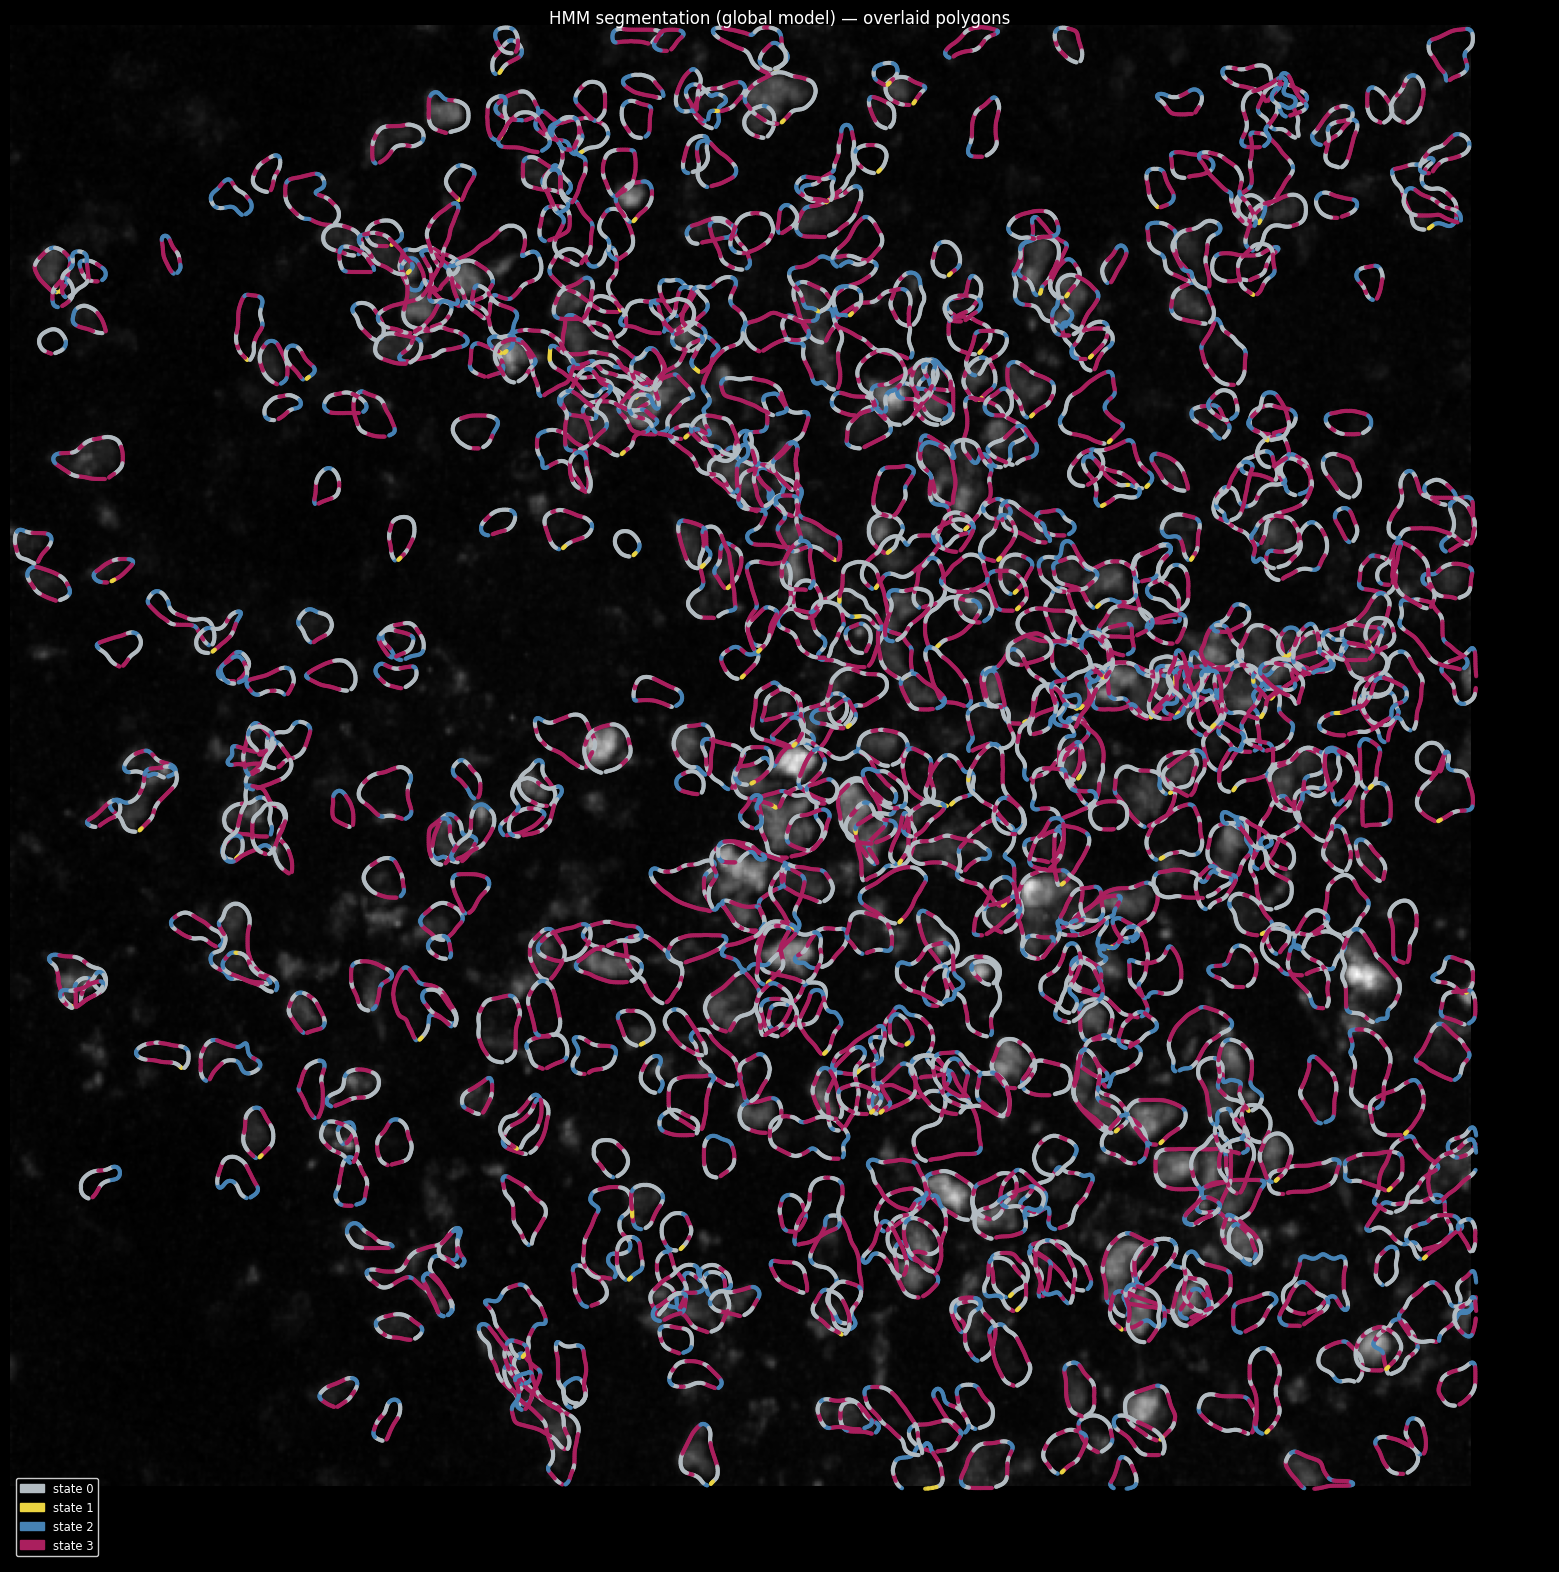

In [24]:
states_list, model, scaler, train_idxs = plot_hmm_polygons(
    polys, sigma=2, n_components=4, train_fraction=0.8, median_w=1, min_run=3,
    return_plot=True, train_on_longest=True)

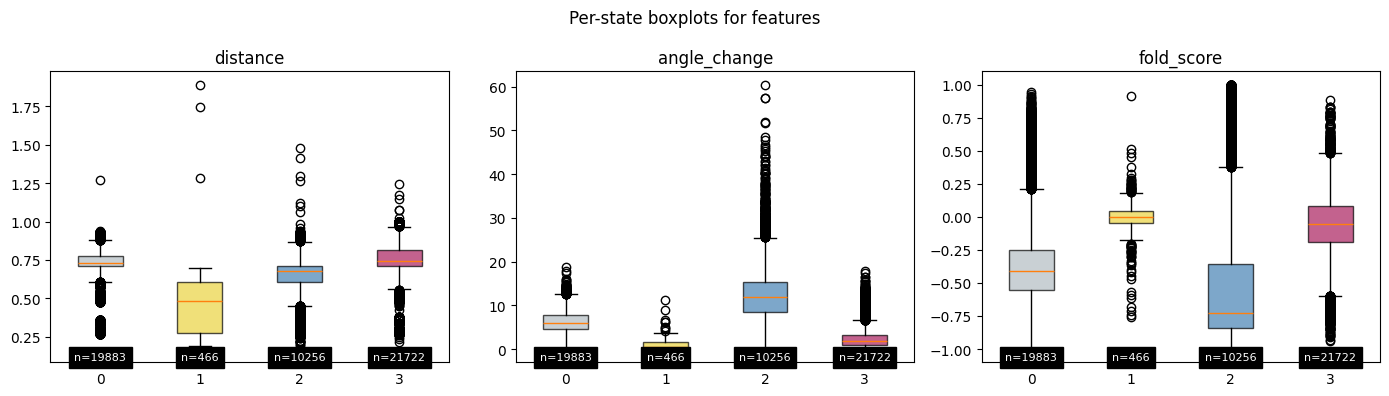

In [25]:
df = plot_state_feature_boxplots(polys, states_list)

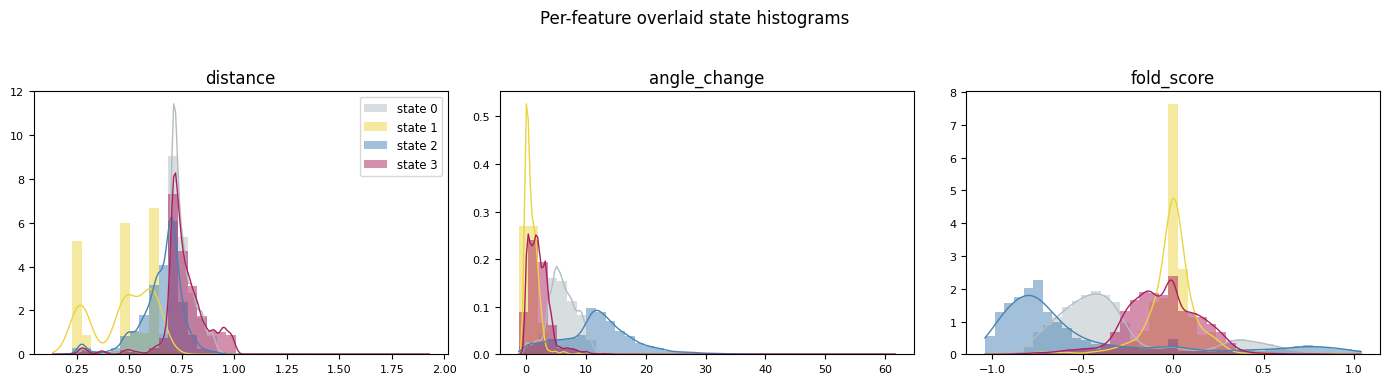

In [26]:
df = plot_state_feature_histograms(polys, states_list)

In [40]:
# get label overlap to capture contact between cells and take
# these interactions into account when tracking cells
import numpy as np
import scipy.ndimage as ndi
from skimage import measure
from shapely.geometry import Polygon
from shapely.ops import unary_union

def calculate_label_contacts(label_volume, dilation_size=1):
    """Calculate label contacts in a 3D volume"""
    # Dilate labels to capture nearby contacts
    struct = np.ones((3, 3, 3), dtype=bool)
    
    # Dictionary to store contacts
    contacts = {}
    
    # Get unique labels
    unique_labels = np.unique(label_volume)[1:]  # Skip background
    
    # Compare each pair of labels
    for i in range(len(unique_labels)):
        for j in range(i+1, len(unique_labels)):
            label1, label2 = unique_labels[i], unique_labels[j]
            
            # Create binary masks and find contact regions
            contact_mask = (label_volume == label1) & (label_volume == label2)
            contact_area = np.sum(contact_mask)
            
            # Store contact if significant
            if contact_area > 0:
                contacts[(label1, label2)] = contact_area
    
    return contacts

def visualize_label_contacts_2d(label_volume, slice_index):
    """Visualize label contacts in a 2D slice"""
    slice_labels = label_volume[slice_index]
    
    # Convert labels to polygons
    label_polygons = {}
    for label in np.unique(slice_labels)[1:]:
        mask = slice_labels == label
        contours = measure.find_contours(mask.astype(np.uint8), 0.5)
        
        # Merge contours into a single polygon
        polys = [Polygon([(float(x), float(y)) for y, x in contour]) 
                 for contour in contours if len(contour) >= 3]
        
        label_polygons[label] = unary_union(polys) if len(polys) > 1 else polys[0]
    
    return label_polygons


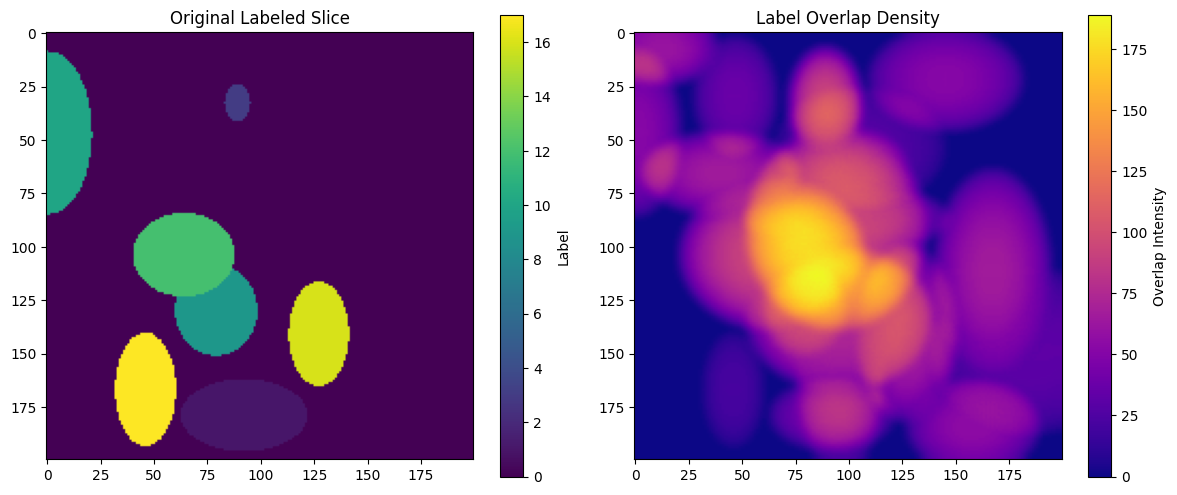

Max overlap density: 189.00
Mean overlap density: 49.27
Unique labels: 20


In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

def generate_complex_label_volume(size=200, num_labels=20):
    """Generate a complex 3D label volume with overlapping regions"""
    label_volume = np.zeros((size, size, size), dtype=np.int32)
    
    for label in range(1, num_labels + 1):
        z, y, x = np.random.randint(0, size, 3)
        a, b, c = np.random.randint(10, 50, 3)
        
        Z, Y, X = np.ogrid[:size, :size, :size]
        blob = ((Z-z)/a)**2 + ((Y-y)/b)**2 + ((X-x)/c)**2 <= 1
        
        noise = np.random.normal(0, 0.1, blob.shape)
        blob_with_noise = blob.astype(float) + noise
        blob_smoothed = gaussian_filter(blob_with_noise, sigma=2) > 0.5
        
        label_volume[blob_smoothed] = label
    
    return label_volume

def calculate_label_overlap_density(label_volume):
    """Calculate 2D overlap density for each label"""
    # Initialize 2D density projection
    overlap_density = np.zeros_like(label_volume[0], dtype=float)
    
    # Count overlaps for each label
    for label in np.unique(label_volume)[1:]:
        # Create binary mask for this label
        label_mask = label_volume == label
        
        # Project label density across Z-axis
        label_density = label_mask.sum(axis=0)
        
        # Normalize and smooth density
        label_density = gaussian_filter(label_density, sigma=2)
        
        # Accumulate to overall overlap density
        overlap_density += label_density
    
    return overlap_density

# Generate volume
np.random.seed(42)
label_volume = generate_complex_label_volume()

# Calculate overlap density
overlap_density = calculate_label_overlap_density(label_volume)

# Visualize
plt.figure(figsize=(12, 5))

# Original labeled slice
plt.subplot(121)
plt.imshow(label_volume[label_volume.shape[0]//2], cmap='viridis')
plt.title('Original Labeled Slice')
plt.colorbar(label='Label')

# Overlap density projection
plt.subplot(122)
plt.imshow(overlap_density, cmap='plasma')
plt.title('Label Overlap Density')
plt.colorbar(label='Overlap Intensity')

plt.tight_layout()
plt.show()

# Optional: print some statistics
print(f"Max overlap density: {overlap_density.max():.2f}")
print(f"Mean overlap density: {overlap_density.mean():.2f}")
print(f"Unique labels: {len(np.unique(label_volume)[1:])}")


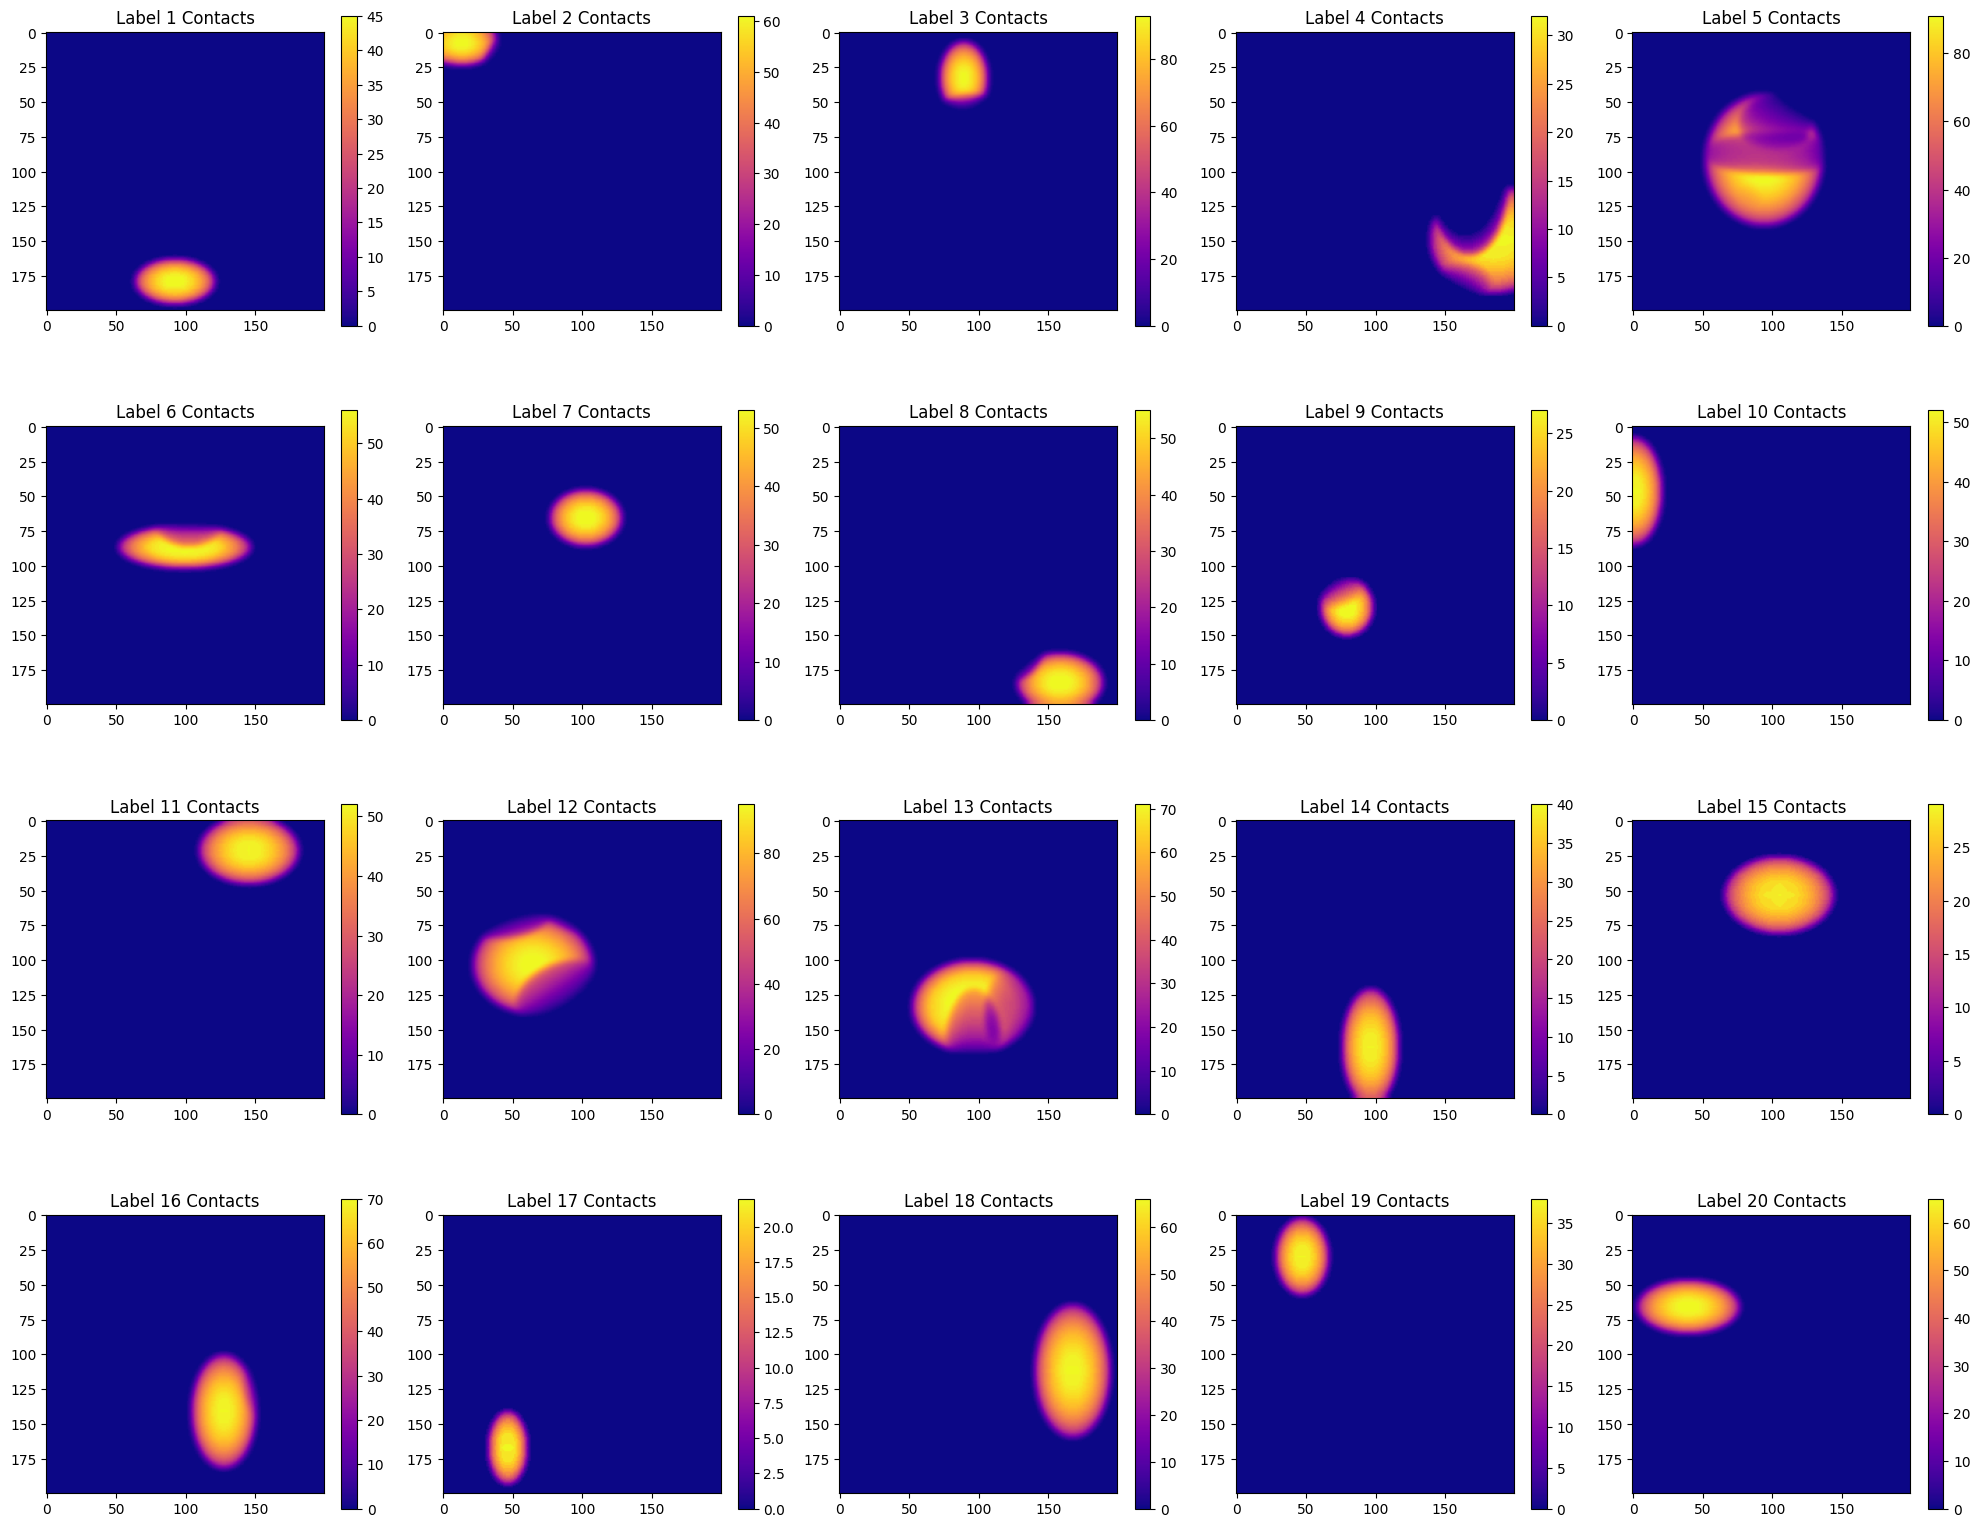

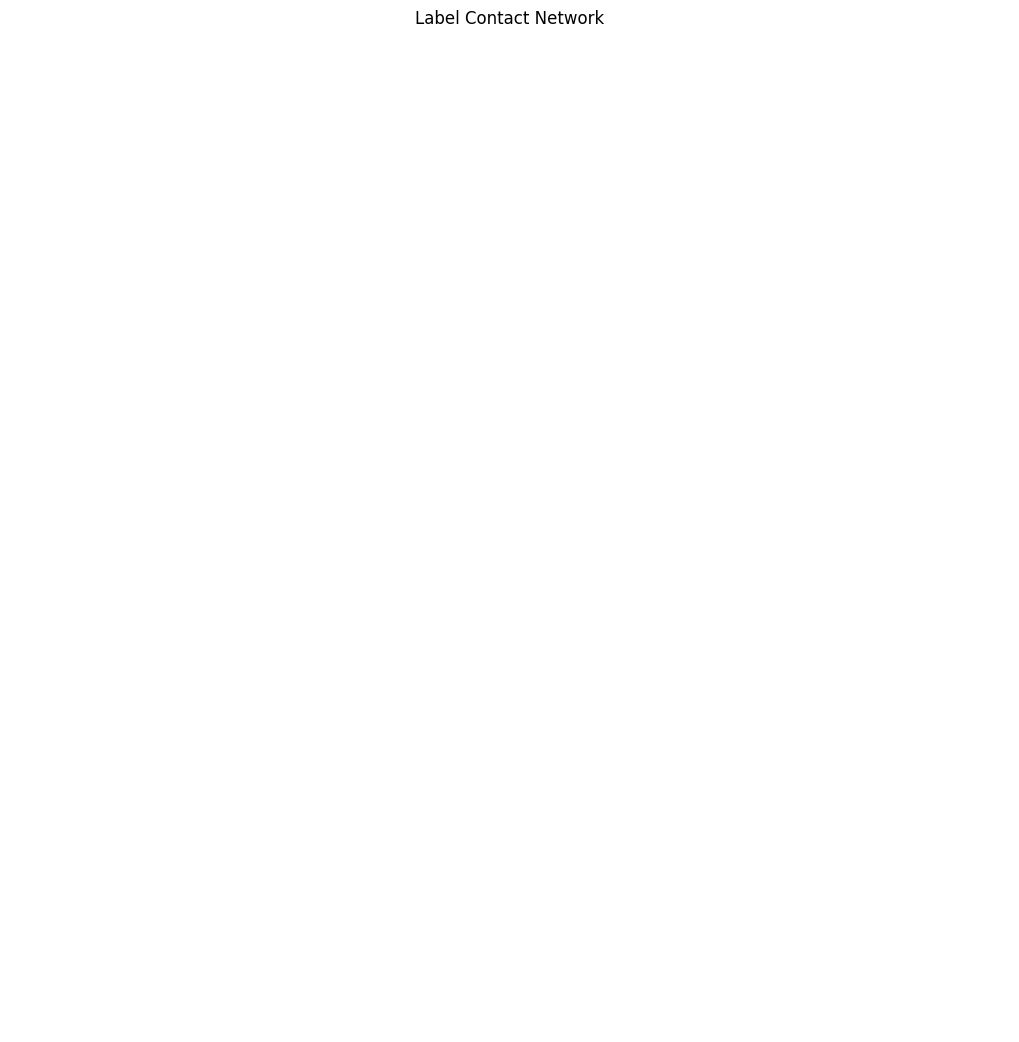

Contact Network Statistics:
Total labels: 0
Total contacts: 0


In [45]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import networkx as nx

def generate_label_volume(size=200, num_labels=20):
    label_volume = np.zeros((size, size, size), dtype=np.int32)
    
    for label in range(1, num_labels + 1):
        z, y, x = np.random.randint(0, size, 3)
        a, b, c = np.random.randint(10, 50, 3)
        
        Z, Y, X = np.ogrid[:size, :size, :size]
        blob = ((Z-z)/a)**2 + ((Y-y)/b)**2 + ((X-x)/c)**2 <= 1
        
        noise = np.random.normal(0, 0.1, blob.shape)
        blob_smoothed = gaussian_filter(blob.astype(float) + noise, sigma=2) > 0.5
        
        label_volume[blob_smoothed] = label
    
    return label_volume

def calculate_label_overlaps(label_volume):
    unique_labels = np.unique(label_volume)[1:]
    contact_graph = nx.Graph()
    
    overlaps = {}
    for label in unique_labels:
        label_mask = label_volume == label
        label_density = gaussian_filter(label_mask.sum(axis=0), sigma=2)
        
        label_overlaps = {}
        for other in unique_labels:
            if other == label:
                continue
            
            overlap = np.sum(label_mask * (label_volume == other))
            if overlap > 0:
                label_overlaps[other] = overlap
                contact_graph.add_edge(label, other, weight=overlap)
        
        overlaps[label] = {
            'density': label_density,
            'contacts': label_overlaps
        }
    
    return overlaps, contact_graph

# Generate and analyze
np.random.seed(42)
label_volume = generate_label_volume()
overlaps, contact_graph = calculate_label_overlaps(label_volume)

# Visualization
fig, axes = plt.subplots(4, 5, figsize=(20, 16))
for i, (label, data) in enumerate(overlaps.items()):
    if i >= len(axes.ravel()):
        break
    
    ax = axes.ravel()[i]
    im = ax.imshow(data['density'], cmap='plasma')
    ax.set_title(f'Label {label} Contacts')
    plt.colorbar(im, ax=ax, shrink=0.8)
    
    contact_text = "\n".join([f"Label {k}: {v}" for k, v in data['contacts'].items()])
    ax.text(0.02, 0.98, contact_text, transform=ax.transAxes, 
            verticalalignment='top', fontsize=8, 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()

# Contact graph visualization
plt.figure(figsize=(10, 10))
nx.draw(contact_graph, with_labels=True, node_color='lightblue', 
        node_size=500, font_size=10, font_weight='bold')
plt.title('Label Contact Network')
plt.show()

# Print contact statistics
print("Contact Network Statistics:")
print(f"Total labels: {len(contact_graph.nodes())}")
print(f"Total contacts: {len(contact_graph.edges())}")


Number of nodes: 20
Number of edges: 124


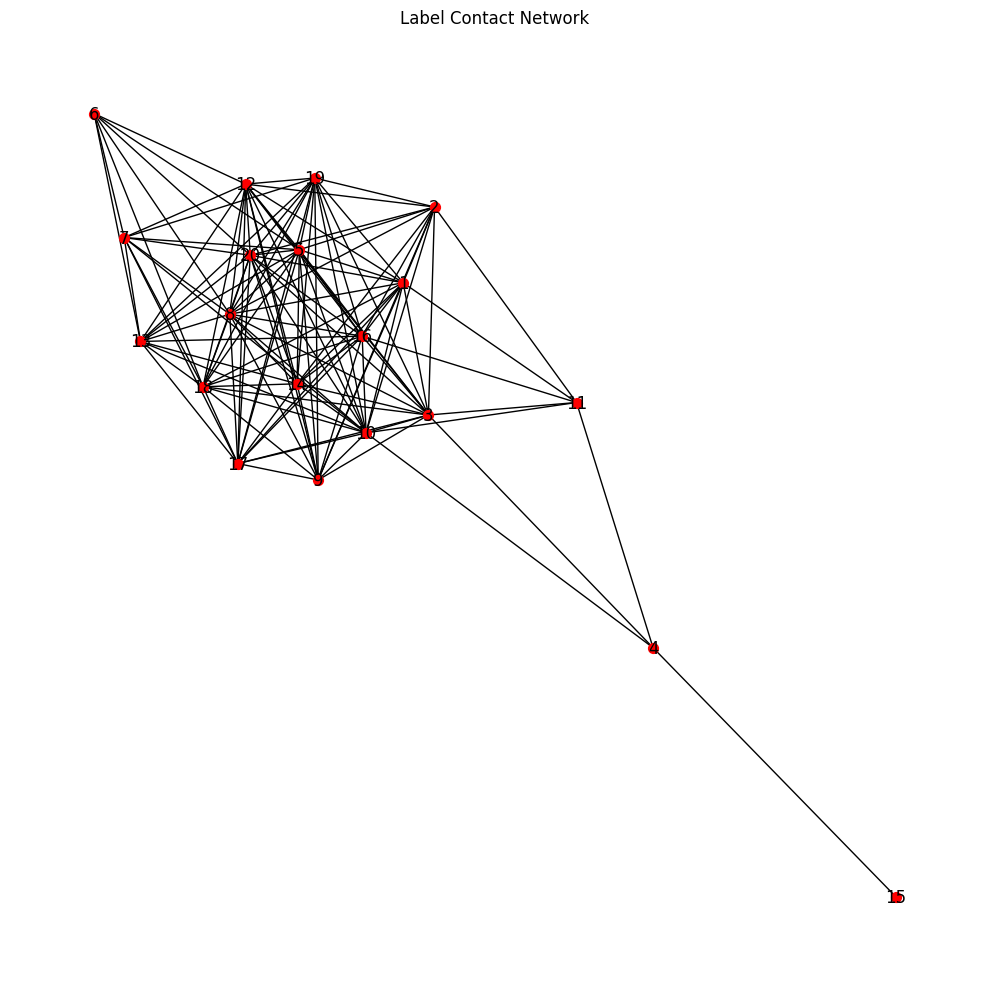

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import networkx as nx

def generate_label_volume(size=200, num_labels=20):
    label_volume = np.zeros((size, size, size), dtype=np.int32)
    
    for label in range(1, num_labels + 1):
        z, y, x = np.random.randint(0, size, 3)
        a, b, c = np.random.randint(10, 50, 3)
        
        Z, Y, X = np.ogrid[:size, :size, :size]
        blob = ((Z-z)/a)**2 + ((Y-y)/b)**2 + ((X-x)/c)**2 <= 1
        
        label_volume[blob] = label
    
    return label_volume

def calculate_label_contacts(label_volume):
    unique_labels = np.unique(label_volume)[1:]
    contact_graph = nx.Graph()
    
    # 3D contact calculation
    for z in range(label_volume.shape[0]):
        slice_labels = np.unique(label_volume[z])
        
        for i in range(len(slice_labels)):
            for j in range(i+1, len(slice_labels)):
                if slice_labels[i] > 0 and slice_labels[j] > 0:
                    contact_graph.add_edge(slice_labels[i], slice_labels[j])
    
    return contact_graph

# Generate volume
np.random.seed(42)
label_volume = generate_label_volume()

# Calculate contacts
contact_graph = calculate_label_contacts(label_volume)

# Visualization
plt.figure(figsize=(10, 10))

# Check graph properties
print(f"Number of nodes: {contact_graph.number_of_nodes()}")
print(f"Number of edges: {contact_graph.number_of_edges()}")

# Ensure graph is not empty before plotting
if contact_graph.edges():
    # Use spring layout
    pos = nx.spring_layout(contact_graph, seed=42)
    
    # Draw nodes and edges
    nx.draw_networkx_nodes(contact_graph, pos, node_color='red', node_size=50)
    nx.draw_networkx_edges(contact_graph, pos)
    nx.draw_networkx_labels(contact_graph, pos)
else:
    print("No contacts found!")

plt.title('Label Contact Network')
plt.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
import os
os.chdir('/home/dominik/Downloads')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from math import atan2, cos, sin
from scipy.optimize import linear_sum_assignment
np.random.seed(7)

# Define the initial state of the T cells (states_proto)
states_proto = np.array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2,
                         2, 2, 2, 2, 1, 1, 1, 1, 2, 2, 2, 2, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2])

# Define the initial coordinates of the T cells (coords_proto)
coords_proto = np.array([
    (591, 11.5), (590, 11.5), (589.5, 11), (589, 10.5), (588, 10.5), (587.5, 10), (587, 9.5),
    (586, 9.5), (585, 9.5), (584, 9.5), (583, 9.5), (582, 9.5), (581, 9.5), (580, 9.5), (579, 9.5),
    (578, 9.5), (577, 9.5), (576, 9.5), (575.5, 9), (575, 8.5), (574.5, 8), (574, 7.5), (573.5, 7),
    (573.5, 6), (574, 5.5), (575, 5.5), (575.5, 5), (576, 4.5), (577, 4.5), (578, 4.5), (579, 4.5),
    (580, 4.5), (580.5, 4), (581, 3.5), (582, 3.5), (583, 3.5), (584, 3.5), (585, 3.5), (585.5, 3),
    (586, 2.5), (587, 2.5), (587.5, 2), (588, 1.5), (589, 1.5), (590, 1.5), (590.5, 2), (591, 2.5),
    (592, 2.5), (593, 2.5), (593.5, 3), (594, 3.5), (595, 3.5), (595.5, 4), (596, 4.5), (597, 4.5),
    (597.5, 5), (598, 5.5), (598.5, 6), (598.5, 7), (598.5, 8), (598, 8.5), (597.5, 9), (597, 9.5),
    (596.5, 10), (596, 10.5), (595, 10.5), (594, 10.5), (593, 10.5), (592, 10.5), (591.5, 11), (591, 11.5)
])

# Define the minimum length of a segment
min_len = 0.8

def segment_from_poly(coords, states, min_len=0.8):
    # Initialize the list of segments
    segs = []
    # Iterate over the states and coordinates
    for i in range(len(states)):
        s = states[i]  # Current state
        j = i + 1  # Next index
        while j < len(states) and states[j] == s:
            j += 1  # Increment the next index until we reach a different state
        pts = coords[i:j]  # Get the coordinates for this segment
        d = (np.sqrt(((pts[1:] - pts[:-1]) ** 2).sum(axis=1)).sum()) if len(pts) > 1 else 0.0
        mid = pts.mean(axis=0)  # Get the mean coordinate of this segment
        vec = pts[-1] - pts[0] if len(pts) > 1 else np.array([1., 0.])
        ori = atan2(vec[1], vec[0])
        segs.append({'state': int(s), 'mid0': mid.copy(), 'mid': mid.copy(), 'len': float(d), 'ori': float(ori)})
    return segs

# Generate the initial segments
proto_segments = segment_from_poly(coords_proto, states_proto, min_len)

# Define the number of time steps to simulate
num_steps = 100

# Initialize the simulated T cell positions and velocities
tcells_pos = np.zeros((2, num_steps))
tcells_vel = np.zeros((2, num_steps))

# Simulate the T cells moving over time
for i in range(num_steps):
    # Get the current segments
    segs = segment_from_poly(coords_proto, states_proto, min_len)
    # Calculate the centroid of each segment
    centroids = np.array([seg['mid'] for seg in segs])
    # Calculate the orientation of each segment
    orientations = np.array([seg['ori'] for seg in segs])
    # Generate random velocities for the T cells based on the segment orientations
    if i < len(orientations):
        tcells_vel[:, i] = np.random.normal(scale=0.1, size=(2,)) * np.array([cos(orientations[i]), sin(orientations[i])])
        # Update the simulated positions of the T cells
        tcells_pos[:, i] = tcells_pos[:, i - 1] + tcells_vel[:, i]

# Plot the results
plt.figure(figsize=(8, 6))
for i in range(num_steps):
    plt.plot(coords_proto[0], coords_proto[1], 'bo-', label='Initial')
    plt.plot(tcells_pos[0, i], tcells_pos[1, i], 'ro-', label='Simulated')
plt.show()

In [ ]:
# tcell_multi_sim_more_motion_final.py
# Requires: numpy, scipy, matplotlib, shapely
import numpy as np, matplotlib.pyplot as plt
from math import atan2, cos, sin
from scipy.optimize import linear_sum_assignment
np.random.seed(7)

state_palette = ["#B3BCC2","#ebd441","#4682b4","#AA1F5E","#4CAF48","#327EBA","#E42328","yellow","cyan"]

coords_proto = np.array([
(591,11.5),(590,11.5),(589.5,11),(589,10.5),(588,10.5),(587.5,10),(587,9.5),
(586,9.5),(585,9.5),(584,9.5),(583,9.5),(582,9.5),(581,9.5),(580,9.5),(579,9.5),
(578,9.5),(577,9.5),(576,9.5),(575.5,9),(575,8.5),(574.5,8),(574,7.5),(573.5,7),
(573.5,6),(574,5.5),(575,5.5),(575.5,5),(576,4.5),(577,4.5),(578,4.5),(579,4.5),
(580,4.5),(580.5,4),(581,3.5),(582,3.5),(583,3.5),(584,3.5),(585,3.5),(585.5,3),
(586,2.5),(587,2.5),(587.5,2),(588,1.5),(589,1.5),(590,1.5),(590.5,2),(591,2.5),
(592,2.5),(593,2.5),(593.5,3),(594,3.5),(595,3.5),(595.5,4),(596,4.5),(597,4.5),
(597.5,5),(598,5.5),(598.5,6),(598.5,7),(598.5,8),(598,8.5),(597.5,9),(597,9.5),
(596.5,10),(596,10.5),(595,10.5),(594,10.5),(593,10.5),(592,10.5),(591.5,11),(591,11.5)
])
states_proto = np.array([2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,1,1,1,1,1,1,1,1,1,1,1,1,2,2,2,2,2,2,2,2,2,
2,2,2,2,1,1,1,1,2,2,2,2,2,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,2,2,2,2,2])

def segment_from_poly(coords, states, min_len=0.8):
    segs=[]; i=0; N=len(states)
    while i<N:
        s=states[i]; j=i+1
        while j<N and states[j]==s: j+=1
        pts=coords[i:j]
        d = (np.sqrt(((pts[1:]-pts[:-1])**2).sum(axis=1)).sum()) if len(pts)>1 else 0.0
        mid=pts.mean(axis=0); vec=pts[-1]-pts[0] if len(pts)>1 else np.array([1.,0.])
        ori=atan2(vec[1],vec[0])
        segs.append({'state':int(s),'mid0':mid.copy(),'mid':mid.copy(),'len':float(d),'ori':float(ori)})
        i=j
    merged=[] 
    for seg in segs:
        if seg['len']<min_len and merged:
            prev=merged[-1]; w1=prev['len']+1e-6; w2=seg['len']+1e-6
            prev['mid0']=(prev['mid0']*w1+seg['mid0']*w2)/(w1+w2); prev['len']+=seg['len']
        else: merged.append(seg)
    return merged

proto_segments = segment_from_poly(coords_proto, states_proto)

# sim params
M=4; T=32
area_center=np.array([560.,8.]); start_spread=26.; min_sep=12.
np.random.seed(11)
centroids=[]
while len(centroids)<M:
    cand=area_center+start_spread*(np.random.randn(2))
    if all(np.linalg.norm(cand-c)> (min_sep*1.6) for c in centroids):  # increase min separation
        centroids.append(cand)

cells=[]
for i in range(M):
    centroid0 = np.array([c['mid0'] for c in proto_segments]).mean(axis=0)
    ang = np.random.rand()*2*np.pi
    speed_run = 2.4 + 0.7*np.random.rand()
    # Create deep copy of segments with proper pseudopod initialization
    segs_copy = []
    for seg in proto_segments:
        seg_copy = dict(seg)
        # Initialize ext_state for all segments
        seg_copy['ext_state'] = 1 if seg_copy['state'] == 1 else 0
        segs_copy.append(seg_copy)
    
    cells.append({
        'id': i,
        'centroid': centroid0.copy(),
        'orient': ang,
        'speed_run': speed_run,
        'segs': segs_copy,
        'centroid0': centroid0.copy(),
        'moving': np.random.rand()>0.4,
        'tau_move': np.random.poisson(6)+4,
        'tau_stop': np.random.poisson(4)+2,
        'tau': (np.random.poisson(6)+4) if np.random.rand()>0.4 else (np.random.poisson(4)+2),
        'ppersist': np.random.poisson(3)+2,
        'persistence_timer': np.random.poisson(3)+2
    })

gt_frames=[]
repulsion_strength=0.6; repulsion_radius=12.
# At the top of the simulation loop
turn_noise_run = 0.1  # Much less noise during movement
turn_noise_stop = 1.2  # More turning when stopped
pos_noise_running = 5.2  # Less positional noise when moving
pos_noise_stopped = 0.1  # Minimal movement when stopped
orient_persist_tau = 0.5  # Faster direction changes
stop_speed_decay = 0.7

for t in range(T):
    frame=[]
    for i,c in enumerate(cells):
        steer = np.zeros(2)
        for j,d in enumerate(cells):
            if i==j: continue
            disp = c['centroid'] - d['centroid']; dist = np.linalg.norm(disp)+1e-6
            if dist < repulsion_radius:
                steer += (disp/dist) * repulsion_strength * (repulsion_radius - dist)/repulsion_radius
            c['repel_steer'] = steer
    for c in cells:
        # Pseudopod dynamics - now the PRIMARY driver of behavior
        c['persistence_timer'] -= 1
        if c['persistence_timer'] <= 0:
            # Correlate pseudopod activity with movement state
            for s in c['segs']:
                if s['state'] == 1:
                    if c['moving']:
                        # During movement, high probability of extension
                        s['ext_state'] = 1 if np.random.rand() < 0.7 else 0
                    else:
                        # During stop, low probability of extension
                        s['ext_state'] = 1 if np.random.rand() < 0.15 else 0
            c['persistence_timer'] = c['ppersist'] + np.random.randint(0,3)
    
        c['tau'] -= 1
        if c['tau'] <= 0:
            c['moving'] = not c['moving']
            c['tau'] = np.random.poisson(8)+4 if c['moving'] else np.random.poisson(5)+2
    
        # Calculate pseudopod direction first - this drives everything
        pp = np.zeros(2)
        ext_n = 0
        for s in c['segs']:
            if s['state']==1 and s.get('ext_state',0)==1:
                d = np.array([cos(s['ori']), sin(s['ori'])])
                pp += d * max(0.1, s['len'])
                ext_n += 1
        
        # Movement is now DETERMINED by pseudopod state
        if ext_n > 0 and np.linalg.norm(pp) > 1e-6:
            # If pseudopods are extended, cell MUST move
            c['moving'] = True
            c['tau'] = c['tau_move']  # Reset movement timer
            pp = pp/np.linalg.norm(pp)
        else:
            # If no pseudopods, cell MUST stop
            c['moving'] = False
            c['tau'] = c['tau_stop']  # Reset stop timer
            pp = None
        
        if c['moving']:
            # Direction is STRONGLY biased towards pseudopods
            if pp is not None:
                target_theta = atan2(pp[1], pp[0])
                mix = 0.85  # Strong bias towards pseudopod direction
            else:
                target_theta = c['orient']
                mix = 0.3
            
            cx = cos(c['orient']); cy = sin(c['orient'])
            tx = cos(target_theta); ty = sin(target_theta)
            bx = (1-mix)*cx + mix*tx; by = (1-mix)*cy + mix*ty
            target_theta = atan2(by, bx)
            
            # Add repulsion
            rs = c['repel_steer']
            if np.linalg.norm(rs) > 1e-6:
                rtheta = atan2(rs[1], rs[0])
                away_theta = rtheta + np.pi
                mix2 = 0.3
                cx = cos(target_theta); cy = sin(target_theta)
                ax = cos(away_theta); ay = sin(away_theta)
                bx = (1-mix2)*cx + mix2*ax; by = (1-mix2)*cy + mix2*ay
                target_theta = atan2(by, bx)
            
            # Less noise during active movement
            dtheta = np.random.randn()*turn_noise_run * 0.5
            c['orient'] = target_theta + dtheta  # Direct change, not smooth
            
            # Speed is proportional to number of extended pseudopods
            speed_factor = min(ext_n / 3.0, 1.0)  # Normalize to max 3 pseudopods
            speed = c['speed_run'] * (0.7 + 0.3*speed_factor) * (0.9 + 0.2*np.random.rand())
            
            v = speed * np.array([cos(c['orient']), sin(c['orient'])])
            v += 0.3 * c['repel_steer']  # Less repulsion influence
            sp = np.linalg.norm(v)
            max_speed = 8.0 * speed_factor
            if sp > max_speed:
                v = v / sp * max_speed
            c['centroid'] = c['centroid'] + v + pos_noise_running * np.random.randn(2) * 0.5
            c['v'] = v
        else:
            # STOPPED state - very little movement
            c['orient'] = c['orient'] + np.random.randn()*turn_noise_stop
            v = c.get('v', np.array([0.0,0.0])) * (stop_speed_decay * 0.5)
            c['centroid'] = c['centroid'] + v + pos_noise_stopped * np.random.randn(2)
            c['v'] = v
    
        # Update segments with more dramatic shape changes
        for s in c['segs']:
            rel = s['mid0'] - c['centroid0']
            mid = c['centroid'] + rel
            
            if s['state']==1:  # Pseudopod
                if s.get('ext_state',0)==1:
                    # Strong extension during movement
                    extension = 2.5 + 0.8*np.random.rand()
                    mid += extension * np.array([cos(s['ori']), sin(s['ori'])])
                    s['len'] = min(s['len'] * 1.15, s['len'] + 0.4)
                else:
                    # Retraction
                    mid -= 1.2 * np.array([cos(s['ori']), sin(s['ori'])])
                    s['len'] = max(s['len'] * 0.85, s['len'] - 0.3)
            elif s['state']==3:  # Inward curvature
                mid -= 0.9*np.array([cos(s['ori']), sin(s['ori'])])
                s['len'] = max(s['len'] * 0.85, s['len'] - 0.2)
            
            mid += 0.15*np.random.randn(2)
            s['mid'] = mid
            
            # Update orientation to follow movement direction
            if c['moving'] and s['state']==1 and s.get('ext_state',0)==1:
                s['ori'] = c['orient'] + np.random.randn()*0.2
                
        # Dynamic state transitions (add after persistence_timer update)
        if np.random.rand() < 0.05:  # 5% chance per timestep
            for s in c['segs']:
                # Straight boundary can become pseudopod
                if s['state'] in [0,2] and np.random.rand() < 0.1:
                    s['state'] = 1
                    s['ext_state'] = 1
                # Pseudopod can become straight boundary
                elif s['state']==1 and np.random.rand() < 0.08:
                    s['state'] = np.random.choice([0,2])
                    s['ext_state'] = 0
                # Any segment can develop inward curvature
                elif np.random.rand() < 0.03:
                    s['state'] = 3
                    
        # Update reference centroid every 10 timesteps to track shape changes
        if t % 10 == 0:
            c['centroid0'] = c['centroid'].copy()
            for s in c['segs']:
                s['mid0'] = s['mid'].copy()
                
        frame.append({'id':c['id'],'centroid':c['centroid'].copy(),'segs':[{'mid':s['mid'].copy(),'state':s['state'],'ori':s['ori'],'len':s['len']} for s in c['segs']]})
    gt_frames.append(frame)

# simple Kalman centroid+vel + segment relative vectors
A=np.array([[1,0,1,0],[0,1,0,1],[0,0,1,0],[0,0,0,1]]); H=np.array([[1,0,0,0],[0,1,0,0]])
Q=np.diag([0.8,0.8,3.0,3.0]); R=np.diag([4.0,4.0]); P0=np.eye(4)*4.0
next_track_id=0; tracks=[]

def predict_track(tr):
    tr['x']=A.dot(tr['x']); tr['P']=A.dot(tr['P']).dot(A.T)+Q; tr['age']+=1

def update_track(tr, meas_centroid, meas_segs, alpha_seg=0.5):
    z=meas_centroid; S=H.dot(tr['P']).dot(H.T)+R; K=tr['P'].dot(H.T).dot(np.linalg.inv(S))
    y=z-H.dot(tr['x']); tr['x']=tr['x']+K.dot(y); tr['P']=(np.eye(4)-K.dot(H)).dot(tr['P'])
    obs_rel=[s['mid']-tr['x'][:2] for s in meas_segs]; L=min(len(tr['segs_rel']),len(obs_rel))
    for i in range(L): tr['segs_rel'][i]=(1-alpha_seg)*tr['segs_rel'][i]+alpha_seg*obs_rel[i]
    for i in range(L,len(obs_rel)): tr['segs_rel'].append(obs_rel[i].copy()); tr['segs_meta'].append((meas_segs[i]['state'],meas_segs[i]['ori'],meas_segs[i]['len']))
    tr['age']=0

def init_track(meas):
    global next_track_id; x=np.array([meas['centroid'][0],meas['centroid'][1],0.,0.]); P=P0.copy()
    segs_rel=[s['mid']-x[:2] for s in meas['segs']]; segs_meta=[(s['state'],s['ori'],s['len']) for s in meas['segs']]
    tr={'track_id':next_track_id,'x':x,'P':P,'segs_rel':segs_rel,'segs_meta':segs_meta,'age':0}; next_track_id+=1; return tr

def cost_track_meas(tr, meas, w_c=1.0, w_m=1.0):
    pred_cent=tr['x'][:2]; cdist=np.linalg.norm(pred_cent-meas['centroid'])
    K=min(len(tr['segs_rel']),len(meas['segs'])); morph=0.0
    for i in range(K):
        pred_mid=pred_cent+tr['segs_rel'][i]; obs_mid=meas['segs'][i]['mid']
        dpos=np.linalg.norm(pred_mid-obs_mid); dori=1.0-np.cos(tr['segs_meta'][i][1]-meas['segs'][i]['ori'])
        dlen=abs(tr['segs_meta'][i][2]-meas['segs'][i]['len']); state_pen=0.0 if tr['segs_meta'][i][0]==meas['segs'][i]['state'] else 1.0
        morph += dpos + 0.9*dori + 0.35*dlen + 2.2*state_pen
    morph = morph/K if K>0 else 0.0
    return w_c*cdist + w_m*morph

results=[]
for t in range(T):
    measurements=gt_frames[t]
    for tr in tracks: predict_track(tr)
    if not tracks:
        for m in measurements: tracks.append(init_track(m))
        mapping={m['id']:tracks[i]['track_id'] for i,m in enumerate(measurements)}; results.append({'assign':mapping.copy(),'tracks':[dict(tr) for tr in tracks]}); continue
    C=np.zeros((len(tracks),len(measurements)))
    for i,tr in enumerate(tracks):
        for j,m in enumerate(measurements): C[i,j]=cost_track_meas(tr,m)
    row_ind,col_ind=linear_sum_assignment(C); assigned_tracks=set(); assigned_meas=set(); mapping={}
    cost_thresh=45.0
    for r,c in zip(row_ind,col_ind):
        if C[r,c]<cost_thresh:
            update_track(tracks[r], measurements[c]['centroid'], measurements[c]['segs'])
            assigned_tracks.add(r); assigned_meas.add(c); mapping[measurements[c]['id']]=tracks[r]['track_id']
    for j,m in enumerate(measurements):
        if j not in assigned_meas:
            tr=init_track(m); tracks.append(tr); mapping[m['id']]=tr['track_id']
    tracks=[tr for tr in tracks if tr['age']<12]
    results.append({'assign':mapping.copy(),'tracks':[dict(tr) for tr in tracks]})

# fragmentation print
track_hist={}
for t,fr in enumerate(results):
    for gtid,tid in fr['assign'].items(): track_hist.setdefault(gtid,[]).append(tid)
print("Fragmentation:", {gt:len(set(ids)) for gt,ids in track_hist.items()})

# Visualization: plot all frames history in gray (older lighter), latest colored, auto bounds with margin
paths = {i:[] for i in range(M)}
for fr in gt_frames:
    for m in fr:
        paths[m['id']].append(m['centroid'].copy())

fig,ax=plt.subplots(1,1,figsize=(10,10)); ax.set_aspect('equal')
all_pts=[s['mid'] for fr in gt_frames for m in fr for s in m['segs']]; all_pts=np.array(all_pts)
xmin,ymin=all_pts.min(axis=0)-8; xmax,ymax=all_pts.max(axis=0)+8

for cid,pts in paths.items():
    pts = np.array(pts)
    if len(pts)>1:
        for k in range(1,len(pts)):
            alpha = 0.12 + 0.88*(k/len(pts))  # older lighter, newer darker
            ax.plot(pts[:k+1,0], pts[:k+1,1], '-', color='C{}'.format(cid%10), linewidth=1.0, alpha=alpha)
            ax.scatter(pts[-1,0], pts[-1,1], c='C{}'.format(cid%10), s=24, edgecolor='k')

for t in range(T):
    gray = '0.7'
    for m in gt_frames[t]:
        mids = np.array([s['mid'] for s in m['segs']])
        ax.plot(np.r_[mids[:,0],mids[0,0]], np.r_[mids[:,1],mids[0,1]], '-', color=gray, linewidth=0.6, alpha=0.5)
# latest frame colored and annotations
for m in gt_frames[-1]:
    mids=np.array([s['mid'] for s in m['segs']]); ax.plot(np.r_[mids[:,0],mids[0,0]],np.r_[mids[:,1],mids[0,1]],'-',color='0.15',linewidth=1.2)
    ax.scatter(m['centroid'][0],m['centroid'][1],c='black',s=30)
    for s in m['segs']:
        col=state_palette[s['state']%len(state_palette)]; ax.plot(s['mid'][0],s['mid'][1],'o',color=col,markersize=6)
    ax.text(m['centroid'][0]+0.4,m['centroid'][1]+0.4,f'GT{m["id"]}',fontsize=8)
# overlay tracker centroids and IDs per last result
for tr in results[-1]['tracks']:
    x=tr['x']; ax.scatter(x[0],x[1],marker='x',c='orange',s=30); ax.text(x[0]+0.2,x[1]-0.3,f'T{tr["track_id"]}',color='orange',fontsize=8)
ax.set_xlim(xmin,xmax); ax.set_ylim(ymin,ymax); ax.invert_yaxis(); plt.tight_layout(); plt.savefig('tcell_multi_sim_more_motion.png',dpi=200)
#print('Saved tcell_multi_sim_more_motion.png')
plt.gca().invert_yaxis()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Polygon
from scipy.spatial import cKDTree
np.random.seed(3)

state_palette = [
    "#B3BCC2", "#ebd441", "#4682b4", "#AA1F5E",
    "#4CAF48", "#327EBA", "#E42328", "yellow", "cyan"
]

FRAMES = 24
DT = 1.0
BASE_SPEED_UM_PER_S = 12.0/60.0
SCALE = 10.0          # increase visible displacement
BASE_SPEED = BASE_SPEED_UM_PER_S * SCALE

class Kalman2D:
    def __init__(self, dt=1.0, q=1e-3, r=1e-2):
        self.dt=dt
        self.x=np.zeros(4); self.P=np.eye(4)
        self.F=np.array([[1,0,dt,0],[0,1,0,dt],[0,0,1,0],[0,0,0,1]])
        self.Q=np.eye(4)*q
        self.H=np.array([[1,0,0,0],[0,1,0,0]])
        self.R=np.eye(2)*r
    def init(self,pos):
        self.x[:2]=pos; self.x[2:]=0.0
    def update(self,z):
        self.x = self.F.dot(self.x)
        self.P = self.F.dot(self.P).dot(self.F.T) + self.Q
        S = self.H.dot(self.P).dot(self.H.T) + self.R
        K = self.P.dot(self.H.T).dot(np.linalg.inv(S))
        y = z - self.H.dot(self.x)
        self.x = self.x + K.dot(y)
        self.P = (np.eye(4)-K.dot(self.H)).dot(self.P)
        return self.x[:2].copy()

def segment_geometry(poly):
    coords = np.array(poly.exterior.coords[:-1])
    seg_mid = []; seg_vec = []; seg_norm = []
    for i in range(len(coords)):
        a = coords[i]; b = coords[(i+1)%len(coords)]
        mid = 0.5*(a+b)
        v = b - a
        v_unit = v / (np.linalg.norm(v)+1e-8)
        n = np.array([-v_unit[1], v_unit[0]])
        seg_mid.append(mid); seg_vec.append(v_unit); seg_norm.append(n)
    return np.array(seg_mid), np.array(seg_vec), np.array(seg_norm)

def local_deform(state, normal, tangent, base_speed=BASE_SPEED):
    # stronger, faster, biased motions
    if state==1:
        if np.random.rand() < 0.8:
            r = np.random.normal(4.0*base_speed, 0.8*base_speed)   # strong outward
        else:
            r = np.random.normal(0.3*base_speed, 0.2*base_speed)
        t = np.random.normal(0.0, 0.6*base_speed)
    elif state==3:
        if np.random.rand() < 0.8:
            r = -abs(np.random.normal(3.5*base_speed, 0.8*base_speed)) # strong inward
        else:
            r = -abs(np.random.normal(0.6*base_speed, 0.25*base_speed))
        t = np.random.normal(0.0, 0.7*base_speed)
    else:
        if np.random.rand() < 0.9:
            t = np.random.normal(2.0*base_speed, 0.5*base_speed)  # steady tangential drift
            r = np.random.normal(0.08*base_speed, 0.06*base_speed)
        else:
            t = np.random.normal(0.6*base_speed, 0.4*base_speed)
            r = np.random.normal(1.2*base_speed, 0.4*base_speed)
    return normal*r + tangent*t

def simulate_polygon_morphology(poly, seg_states, frames=FRAMES, state_change_p=0.25):
    coords0 = np.array(poly.exterior.coords)[:-1]    # ordered ring of vertices
    n = len(coords0)

    def vertex_geom(coords):
        nxt = np.roll(coords, -1, axis=0)
        v = nxt - coords
        vlen = np.linalg.norm(v, axis=1, keepdims=True) + 1e-8
        tang = v / vlen
        norm = np.column_stack([-tang[:,1], tang[:,0]])
        mid = 0.5*(coords + nxt)
        return mid, tang, norm

    # resample seg_states to per-vertex states (preserve circular alignment)
    m = len(seg_states)
    if m != n:
        src = np.linspace(0,1,m,endpoint=False)
        dst = np.linspace(0,1,n,endpoint=False)
        idx = np.argmin(np.abs(dst[:,None]-src[None,:]), axis=1)
        states = np.array(seg_states)[idx].astype(int)
    else:
        states = np.array(seg_states).astype(int)

    cur = coords0.copy()
    frames_polys = [cur.copy()]; frames_states = [states.copy()]
    global_pos = cur.mean(axis=0); global_positions = [global_pos.copy()]

    # parameters controlling cohesion and max per-frame normal movement
    max_normal_disp = 1.5 * BASE_SPEED       # clamp per-frame normal displacement
    influence_out_in = 0.9                   # influence for pseudopod/inward states
    influence_other = 0.5                     # influence for neutral states
    smoothing_alpha = 0.10                    # neighbor smoothing weight

    for f in range(1, frames):
        # state transitions per vertex
        for i in range(n):
            if np.random.rand() < state_change_p:
                s = int(states[i])
                if s in (0,2):
                    states[i] = np.random.choice([0,1,2,3], p=[0.45,0.35,0.15,0.05])
                elif s == 1:
                    states[i] = np.random.choice([1,0,2,3], p=[0.65,0.2,0.1,0.05])
                elif s == 3:
                    states[i] = np.random.choice([3,0,2,1], p=[0.65,0.2,0.1,0.05])

        # per-vertex geometry
        mid, tang, norm = vertex_geom(cur)

        # compute raw local displacements (may contain tangential + normal)
        raw_disps = np.zeros_like(cur)
        for i in range(n):
            raw_disps[i] = local_deform(int(states[i]), norm[i], tang[i])

        # keep only normal component to avoid tangential sliding; clamp magnitudes
        normal_mag = np.sum(raw_disps * norm, axis=1)           # signed scalar along normal
        max_normal_disp = 0.9 * BASE_SPEED                      # tighter clamp
        normal_mag = np.clip(normal_mag, -max_normal_disp, max_normal_disp)
        normal_disps = norm * normal_mag[:, None]

        # Debug: first-frame summary
        if f == 1:
            print("DEBUG: first-frame states[:12]:", states[:12])
            print("DEBUG: first-frame normal_disp mags[:12]:", normal_mag[:12])

        # --- persistent polarity state (create once) ---
        # Attach a polarity vector to the function scope (on first call it will be created)
        if not hasattr(simulate_polygon_morphology, "_polarity"):
            simulate_polygon_morphology._polarity = np.array([1.0, 0.0])  # initial polarity (x-axis)
            simulate_polygon_morphology._polarity_strength = 0.0

        pol = simulate_polygon_morphology._polarity
        pol_strength = simulate_polygon_morphology._polarity_strength

        # compute per-vertex forward alignment to polarity (dot of vertex normal with polarity)
        # use normals (outward) — vertices whose normal aligns with polarity are "front"
        align = np.dot(norm, pol)   # length n array, in [-1,1]

        # boost normal displacement for front-facing vertices to create protrusions in front
        front_boost = 1.0 + 1.6 * np.clip(align, 0.0, 1.0)   # 1x to 2.6x boost in front
        normal_disp_boosted = normal_disps * front_boost[:, None]

        # compute robust per-vertex step (incremental as before)
        infl = np.where(np.isin(states, [1,3]), 0.9, 0.5)[:, None]
        beta = 0.20   # slightly larger fraction to increase membrane activity
        normal_step = infl * normal_disp_boosted * beta

        # base rigid translation from median of boosted normal steps (keep previous robust mix)
        trans_base = np.median(normal_step, axis=0)
        trans_base = 0.25 * trans_base + 0.75 * normal_step.mean(axis=0)

        # add explicit polarity-driven translation to produce persistent migration
        # polarity magnitude is proportional to polarity_strength (stateful) and to average front protrusion
        avg_front = np.mean(np.maximum(0.0, align) * np.linalg.norm(normal_step, axis=1))
        # update polarity strength slowly: increase when front protrudes, decay otherwise
        pol_strength = 0.85 * pol_strength + 0.35 * avg_front
        # normalize / clamp polarity vector magnitude
        pol_mag = np.linalg.norm(pol) + 1e-8
        pol = pol / pol_mag
        # small random perturbation to allow turning
        pol += 0.05 * np.random.normal(scale=1.0, size=2)
        pol = pol / (np.linalg.norm(pol) + 1e-8)

        simulate_polygon_morphology._polarity = pol
        simulate_polygon_morphology._polarity_strength = pol_strength

        # polarity translation vector (scale by strength)
        pol_translate = pol * (0.9 * pol_strength + 0.06 * BASE_SPEED)

        # combine base translation and polarity translation (pol increases net displacement)
        trans = trans_base + pol_translate

        # rotation estimate as before but slightly increased sensitivity to tangential tendency
        cen = cur.mean(axis=0)
        rel = mid - cen
        tang_comp = np.sum(raw_disps * tang, axis=1)
        rot_num = np.sum(tang_comp * np.linalg.norm(rel, axis=1))
        rot_den = np.sum(np.linalg.norm(rel, axis=1)**2) + 1e-8
        theta = 0.0012 * (rot_num / rot_den)   # slightly larger rotation factor for turning
        c, s = np.cos(theta), np.sin(theta)
        R = np.array([[c, -s],[s, c]])

        # apply rigid transform
        cur_rigid = ((cur - cen).dot(R.T)) + cen + trans

        # apply incremental normal step (already boosted) and cohesion + smoothing as before
        cur_after = cur_rigid + normal_step

        # cohesion toward neighbor midpoint (retain gamma from before)
        gamma = 0.45
        neighbor_mid = 0.5 * (np.roll(cur_after, 1, axis=0) + np.roll(cur_after, -1, axis=0))
        cohesion_correction = gamma * (neighbor_mid - cur_after)
        cur_cohesed = cur_after + cohesion_correction

        # smoothing alpha slightly reduced since we use stronger cohesion
        alpha = 0.05
        nbr_avg = 0.5 * (np.roll(cur_cohesed, 1, axis=0) + np.roll(cur_cohesed, -1, axis=0))
        v_smooth = (1.0 - alpha) * cur_cohesed + alpha * nbr_avg

        # preserve mean radius
        cen2 = v_smooth.mean(axis=0)
        r_before = np.mean(np.linalg.norm(cur_after - cen2, axis=1))
        r_after = np.mean(np.linalg.norm(v_smooth - cen2, axis=1))
        if r_after > 1e-8:
            v_smooth = cen2 + (v_smooth - cen2) * (r_before / r_after)

        cur = v_smooth

        # calculate initial area
        initial_area = 0.5 * np.abs(np.dot(cur[:,0], np.roll(cur[:,1], -1)) - np.dot(cur[:,1], np.roll(cur[:,0], -1)))

        # --- Angle-sort, smooth radii, resample, then adjust radii to exactly match area ---
        cen = cur.mean(axis=0)
        rel = cur - cen
        angles = np.arctan2(rel[:,1], rel[:,0])
        radii = np.linalg.norm(rel, axis=1)

        # order by angle to ensure monotonic traversal
        order = np.argsort(angles)
        angles_s = angles[order]
        radii_s = radii[order]

        # smooth radii (small amount)
        def smooth_r(r, w=0.18, iters=3):
            r2 = r.copy()
            for _ in range(iters):
                r2 = (1.0 - w) * r2 + w * 0.5 * (np.roll(r2,1) + np.roll(r2,-1))
            return r2
        radii_s = smooth_r(radii_s, w=0.18, iters=3)

        # resample to uniform angles
        m = len(cur)
        ang_uniform = np.linspace(-np.pi, np.pi, m, endpoint=False)
        angles_unwrap = np.unwrap(angles_s)
        ang_ext = np.concatenate([angles_unwrap - 2*np.pi, angles_unwrap, angles_unwrap + 2*np.pi])
        rad_ext = np.tile(radii_s, 3)
        from numpy import interp
        radii_interp = interp(ang_uniform, ang_ext, rad_ext)

        # build candidate ring
        cur_new = np.column_stack([cen[0] + radii_interp * np.cos(ang_uniform),
                                   cen[1] + radii_interp * np.sin(ang_uniform)])

        # mild Laplacian smoothing
        alpha_s = 0.06
        nbr = 0.5*(np.roll(cur_new,1,axis=0) + np.roll(cur_new,-1,axis=0))
        cur_new = (1.0 - alpha_s) * cur_new + alpha_s * nbr

        # function to compute polygon area
        def poly_area(pts):
            x = pts[:,0]; y = pts[:,1]
            return 0.5 * (np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))

        # target signed area from source (preserve orientation sign too)
        area_target = poly_area(v_smooth)
        area_cand = poly_area(cur_new)
        # if candidate area is already close, accept
        if abs(area_cand - area_target) > 1e-6:
            # First apply global scale about centroid (good initial guess)
            s0 = (abs(area_target) / (abs(area_cand) + 1e-16))**0.5
            cur_scaled = cen + (cur_new - cen) * s0
            area_scaled = poly_area(cur_scaled)

            # If further correction needed, do one Newton-style multiplicative radial correction:
            # solve for small rho(theta) = a + b*cos(2*theta) weighting -> approximate correction using radial factor r -> r*(1 + eps*phi)
            # Here we use a simple per-vertex multiplicative correction direction proportional to local radial derivative of area:
            thetas = np.arctan2((cur_scaled - cen)[:,1], (cur_scaled - cen)[:,0])
            # approximate area sensitivity per-vertex to a multiplicative radial change
            # dA ≈ sum_i (0.5 * (r_i * r_{i+1}) * sin(delta_theta_i)) * eps_i  but we approximate with wedge areas
            xs = cur_scaled[:,0]; ys = cur_scaled[:,1]
            # compute per-edge mid-wedge area contributions for small multiplicative change
            wedge = 0.5 * (xs * np.roll(ys, -1) - ys * np.roll(xs, -1))
            # construct per-vertex influence approx by averaging adjacent wedges
            influence = 0.5 * (wedge + np.roll(wedge, 1))
            # choose correction eps per vertex proportional to influence * sign(area_target - area_scaled)
            resid = (area_target - area_scaled)
            if np.abs(np.sum(influence)) < 1e-16:
                # fallback to uniform scaling if degenerate
                cur = cen + (cur_scaled - cen) * (1.0 + resid / (area_scaled + 1e-16))
            else:
                # compute a small scalar alpha so that sum(influence * alpha * factor) ≈ resid
                # pick per-vertex multiplier proportional to influence
                alpha = resid / (np.sum(influence * (radii_interp + 1e-8)))
                # apply multiplicative radial correction
                dirs = (cur_scaled - cen)
                norms = np.linalg.norm(dirs, axis=1) + 1e-12
                dirs_unit = dirs / norms[:,None]
                # move each vertex radially by factor (1 + alpha * w_i)
                w = influence / (np.max(np.abs(influence)) + 1e-12)
                radial_factor = 1.0 + alpha * w
                cur = cen + (cur_scaled - cen) * radial_factor[:,None]
                # final safeguard: if sign flipped or area still off, fallback to uniform scaling
                if np.sign(poly_area(cur)) != np.sign(area_target) or abs(poly_area(cur) - area_target) > 1e-6:
                    cur = cen + (cur_scaled - cen) * (area_target / (area_scaled + 1e-12))**0.5
        else:
            cur = cur_new

        # after updating cur
        cur_center = cur.mean(axis=0)
        cur_scaled = cur - cur_center
        area = 0.5 * np.abs(np.dot(cur_scaled[:,0], np.roll(cur_scaled[:,1], -1)) - np.dot(cur_scaled[:,1], np.roll(cur_scaled[:,0], -1)))
        scale_factor = np.sqrt(initial_area / area)
        cur = cur_center + cur_scaled * scale_factor

        frames_polys.append(cur.copy())
        frames_states.append(states.copy())
        global_pos = global_pos + trans
        global_positions.append(global_pos.copy())


    # Track + Kalman smoothing as before
    track = np.vstack(global_positions)
    kf = Kalman2D(dt=DT, q=5e-3, r=5e-2)
    kf.init(track[0].copy())
    ktrack = [kf.x[:2].copy()]
    for i in range(1, frames):
        ktrack.append(kf.update(track[i]))
    ktrack = np.array(ktrack)
    return frames_polys, frames_states, track, ktrack

def plot_simulation_frames(poly, seg_states):
    frames_polys, frames_states, track, ktrack = simulate_polygon_morphology(poly, seg_states)
    print('frames_polys[1][:8]')
    print(frames_polys[1][:8])
    print('frames_polys[-1][:8]')
    print(frames_polys[-1][:8])
    picks = np.linspace(0, FRAMES-1, int(max(4,FRAMES)/4), dtype=int)
    n = len(picks)
    fig, axs = plt.subplots(1,n, figsize=(4*n,4))
    if n==1: axs=[axs]
    for ax, idx in zip(axs, picks):
        ax.set_title(f"Frame {idx}")
        for f in range(0, idx):
            p = frames_polys[f]; poly_pts = np.vstack([p, p[0]])
            ax.plot(poly_pts[:,0], poly_pts[:,1], color='lightgray', alpha=0.6)
        p_cur = frames_polys[idx]; s_cur = frames_states[idx]
        for i in range(len(p_cur)):
            a = p_cur[i]; b = p_cur[(i+1)%len(p_cur)]
            st = int(s_cur[i])
            ax.plot([a[0], b[0]], [a[1], b[1]], color=state_palette[st], linewidth=3)
        mids = 0.5*(p_cur + np.roll(p_cur,-1,axis=0))
        ax.scatter(mids[:,0], mids[:,1], c=[state_palette[int(s)] for s in s_cur], edgecolor='k', s=30)
        ax.plot(track[:idx+1,0], track[:idx+1,1], '-o', color='magenta', markersize=4, label='raw track')
        ax.plot(ktrack[:idx+1,0], ktrack[:idx+1,1], '-o', color='cyan', markersize=4, label='kalman')
        ax.axis('equal'); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

if __name__ == "__main__":
    plot_simulation_frames(polys[0], states_list[0])



In [ ]:
# classify_cells_from_polys_and_states.py
import numpy as np
import pandas as pd
from shapely.geometry import Polygon
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score
import math

# --- Geometry helpers ---
def polygon_coords(poly: Polygon):
    x, y = poly.exterior.coords.xy
    return np.vstack([x, y]).T

def polygon_area(poly: Polygon):
    return float(poly.area)

def polygon_perimeter(poly: Polygon):
    return float(poly.length)

def convex_area(poly: Polygon):
    return float(poly.convex_hull.area)

def solidity(poly: Polygon):
    ca = convex_area(poly)
    return float(poly.area) / ca if ca > 0 else 0.0

def bbox_aspect(poly: Polygon):
    minx, miny, maxx, maxy = poly.bounds
    h = maxy - miny
    w = maxx - minx
    return float(w) / h if h > 0 else 0.0

def eccentricity_from_coords(coords):
    coords = coords - coords.mean(axis=0)
    cov = np.cov(coords.T)
    eig = np.linalg.eigvalsh(cov)
    eig = np.sort(eig)[::-1]
    if eig[0] <= 0:
        return 0.0
    return float(1.0 - (eig[1] / eig[0]))

def elongation(coords):
    coords = coords - coords.mean(axis=0)
    d = np.linalg.norm(coords, axis=1)
    return float(d.max() / (np.std(d) + 1e-8))

# --- HMM sequence features ---
def state_percentages(states, n_states=None):
    s = np.asarray(states, dtype=int)
    if n_states is None:
        n_states = int(s.max()) + 1 if s.size>0 else 0
    counts = np.bincount(s, minlength=n_states).astype(float)
    total = counts.sum()
    return (counts / total) if total>0 else np.zeros(n_states, dtype=float)

def transition_matrix_normalized(states, n_states=None):
    s = np.asarray(states, dtype=int)
    if n_states is None:
        n_states = int(s.max()) + 1 if s.size>0 else 0
    if n_states == 0:
        return np.zeros(0, dtype=float)
    mat = np.zeros((n_states, n_states), dtype=float)
    if s.size > 1:
        for a,b in zip(s[:-1], s[1:]):
            mat[a, b] += 1.0
    row_sums = mat.sum(axis=1, keepdims=True)
    with np.errstate(divide='ignore', invalid='ignore'):
        mat = np.divide(mat, row_sums, where=row_sums>0)
    return mat.flatten()

def run_length_stats(states, n_states=None):
    s = np.asarray(states, dtype=int)
    if s.size == 0:
        return np.zeros(0, dtype=float)
    if n_states is None:
        n_states = int(s.max()) + 1
    run_counts = np.zeros(n_states, dtype=float)
    run_maxlen = np.zeros(n_states, dtype=float)
    prev = s[0]; cur = 1
    for v in s[1:]:
        if v == prev:
            cur += 1
        else:
            run_counts[prev] += 1
            run_maxlen[prev] = max(run_maxlen[prev], cur)
            prev = v; cur = 1
    run_counts[prev] += 1
    run_maxlen[prev] = max(run_maxlen[prev], cur)
    L = float(len(s))
    return np.concatenate([run_counts / L, run_maxlen / L])

# --- Feature builder using your variables polys and states_list ---
def build_features_from(polys, states_list, n_states=None, resample_vertices=None):
    """
    polys: list of shapely Polygons
    states_list: list of 1D arrays (HMM state per polygon vertex). Must correspond to polygon boundary sampling.
    n_states: optional number of HMM states (if None inferred)
    resample_vertices: if int, resample polygon boundary to this many vertices (uniform)
    Returns: DataFrame of features
    """
    N = len(polys)
    assert N == len(states_list), "polys and states_list must be same length"
    if n_states is None:
        n_states = max(int(s.max()) for s in states_list if len(s)>0) + 1 if N>0 else 0

    records = []
    for poly, states in zip(polys, states_list):
        if resample_vertices is not None:
            # resample polygon boundary to fixed number of points
            length = poly.length
            if length == 0:
                coords = polygon_coords(poly)
            else:
                distances = np.linspace(0, length, resample_vertices, endpoint=False)
                coords = np.array([poly.exterior.interpolate(d).coords[0] for d in distances])
                # resample/adjust states to same length by nearest or repetition
                s = np.asarray(states, dtype=int)
                if len(s) != resample_vertices:
                    # simple nearest index mapping
                    idxs = np.round(np.linspace(0, len(s)-1, resample_vertices)).astype(int)
                    states = s[idxs]
        else:
            coords = polygon_coords(poly)
            states = np.asarray(states, dtype=int)
            # align lengths if mismatch
            if len(states) != len(coords):
                L = len(coords)
                if len(states) < L:
                    states = np.pad(states, (0, L - len(states)), constant_values=states[-1] if len(states)>0 else 0)
                else:
                    states = states[:L]

        # morphology
        area = polygon_area(poly)
        perim = polygon_perimeter(poly)
        conv_area = convex_area(poly)
        sol = solidity(poly)
        bbox = bbox_aspect(poly)
        ecc = eccentricity_from_coords(coords) if len(coords)>2 else 0.0
        elong = elongation(coords) if len(coords)>2 else 0.0
        perim_over_conv = perim / (conv_area + 1e-8)

        # HMM
        pct = state_percentages(states, n_states=n_states)
        trans = transition_matrix_normalized(states, n_states=n_states)
        runs = run_length_stats(states, n_states=n_states)

        feat = {
            'area': area,
            'perimeter': perim,
            'convex_area': conv_area,
            'solidity': sol,
            'bbox_aspect': bbox,
            'eccentricity': ecc,
            'elongation': elong,
            'perim_over_conv': perim_over_conv,
        }
        for i in range(n_states):
            feat[f'pct_s{i}'] = float(pct[i]) if i < len(pct) else 0.0
        for i in range(n_states):
            feat[f'runcount_s{i}'] = float(runs[i]) if i < len(runs) else 0.0
        for i in range(n_states):
            feat[f'runmaxlen_s{i}'] = float(runs[n_states + i]) if (n_states + i) < len(runs) else 0.0
        # transitions
        for idx, val in enumerate(trans):
            feat[f'trans_{idx}'] = float(val)

        records.append(feat)

    df = pd.DataFrame.from_records(records).fillna(0.0)
    return df

# --- Training / prediction utilities ---
def train_rf_classifier(feature_df, labels, use_pca=True, n_pca=12, random_state=0):
    X = feature_df.values
    y = np.asarray(labels)
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    pca = PCA(n_components=min(n_pca, Xs.shape[1])) if use_pca else None
    Xr = pca.fit_transform(Xs) if use_pca else Xs
    clf = RandomForestClassifier(n_estimators=200, random_state=random_state, n_jobs=-1)
    clf.fit(Xr, y)
    cv = cross_val_score(clf, Xr, y, cv=5) if len(y) >= 10 else None
    return {'clf': clf, 'scaler': scaler, 'pca': pca, 'cv_scores': cv, 'features': feature_df.columns}

def predict_with_bundle(polys, states_list, bundle, n_states=None, resample_vertices=None):
    Xdf = build_features_from(polys, states_list, n_states=n_states, resample_vertices=resample_vertices)
    Xs = bundle['scaler'].transform(Xdf.values)
    if bundle.get('pca') is not None:
        Xr = bundle['pca'].transform(Xs)
    else:
        Xr = Xs
    preds = bundle['clf'].predict(Xr)
    return preds, Xdf

# --- Example usage with your variables polys and states_list ---
if __name__ == "__main__":
    # Expect the user already has 'polys' and 'states_list' defined in their environment.
    try:
        polys  # noqa
        states_list  # noqa
    except NameError:
        raise RuntimeError("Please define 'polys' (list of shapely Polygons) and 'states_list' (list of HMM state arrays) before running.")

    # Build features (auto-detect number of states)
    feat_df = build_features_from(polys, states_list, n_states=None, resample_vertices=64)

    # If you have labels, train:
    # labels = [...]  # same length as polys
    #bundle = train_rf_classifier(feat_df, labels, use_pca=True, n_pca=12)
    #preds, Xdf = predict_with_bundle(polys, states_list, bundle, resample_vertices=64)

    # If no labels, you can export features for clustering
    #feat_df.to_csv("cell_shape_hmm_features.csv", index=False)
    #print("Feature matrix saved to cell_shape_hmm_features.csv with shape", feat_df.shape)


In [ ]:
feat_df

In [ ]:
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import kneighbors_graph
import igraph as ig
import leidenalg

# Standardize
X = StandardScaler().fit_transform(feat_df)

# Build kNN graph (symmetric)
k = 10
A = kneighbors_graph(X, n_neighbors=min(k, X.shape[0]-1), mode='connectivity', include_self=False, n_jobs=1)
A = A.toarray()
# Make symmetric
A = np.maximum(A, A.T)

# Convert adjacency to igraph
g = ig.Graph.Adjacency((A > 0).tolist())
g.vs['name'] = [str(i) for i in range(X.shape[0])]

# Run Leiden
partition = leidenalg.find_partition(g, leidenalg.RBConfigurationVertexPartition, resolution_parameter=0.6, weights=None)
labels = np.array(partition.membership)

# Return pandas DataFrame with features and cluster labels
df = pd.DataFrame(X, columns=[f"f{i}" for i in range(X.shape[1])])
df['cluster'] = labels
print(df['cluster'].value_counts())
print(df)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# optional import
try:
    import umap
    UMAP_AVAILABLE = True
except Exception:
    UMAP_AVAILABLE = False

def plot_cluster_feature_boxplots_wrapped(feature_df, cluster_labels, feature_names=None,
                                          palette=None, show_counts=True, wrap=5,
                                          figsize_per_panel=(4,4), ylabel=None,
                                          embed=False, embed_method='pca', embed_params=None,
                                          violin=False, legend_loc='upper right'):
    """
    Extended: draws box/violin plots per feature grouped by cluster, and optionally a 2D embedding scatter.

    New params:
    - embed: bool -> compute 2D embedding (PCA or UMAP) and plot scatter of clusters above the grid.
    - embed_method: 'pca' or 'umap'
    - embed_params: dict passed to PCA/UMAP (e.g., n_components=2, random_state)
    - violin: bool -> use violins instead of boxplots
    - legend_loc: legend location for cluster colors on embedding

    Returns:
    fig: matplotlib.Figure
    axes: ndarray of axes
    df_long: long-form DataFrame
    embed_coords: ndarray or None (N x 2) if embed=True
    """
    # normalize inputs
    if isinstance(feature_df, np.ndarray):
        if feature_names is None:
            raise ValueError("feature_names required when feature_df is ndarray")
        df = pd.DataFrame(feature_df, columns=feature_names)
    else:
        df = feature_df.copy()
        if feature_names is None:
            feature_names = list(df.columns)

    clusters = np.asarray(cluster_labels)
    if clusters.shape[0] != df.shape[0]:
        raise ValueError("cluster_labels length must match number of rows in feature_df")

    # build palette
    unique_clusters = np.unique(clusters[~pd.isna(clusters)])
    n_clusters = len(unique_clusters)
    if palette is None:
        import matplotlib.cm as cm
        cmap = cm.get_cmap('tab20', max(8, n_clusters))
        palette = {int(c): cmap(i % cmap.N) for i,c in enumerate(unique_clusters)}
    elif isinstance(palette, (list, tuple, np.ndarray)):
        palette = {int(c): palette[i % len(palette)] for i,c in enumerate(unique_clusters)}

    # long-format DataFrame with cluster column
    records = []
    for i, row in df.iterrows():
        cl = clusters[i]
        cl_val = int(cl) if not pd.isna(cl) else -1
        for fn in feature_names:
            records.append({'cluster': cl_val, 'feature': fn, 'value': row[fn]})
    df_long = pd.DataFrame.from_records(records)

    # embedding (optional)
    embed_coords = None
    if embed:
        X = df.values
        if embed_method == 'pca':
            params = {'n_components': 2}
            if embed_params:
                params.update(embed_params)
            pca = PCA(**params)
            embed_coords = pca.fit_transform(X)
        elif embed_method == 'umap':
            if not UMAP_AVAILABLE:
                raise RuntimeError("UMAP not available. Install umap-learn or set embed_method='pca'.")
            params = {'n_components': 2}
            if embed_params:
                params.update(embed_params)
            reducer = umap.UMAP(**params)
            embed_coords = reducer.fit_transform(X)
        else:
            raise ValueError("embed_method must be 'pca' or 'umap'")

    # layout: if embedding, allocate a top row for scatter
    n_features = len(feature_names)
    ncols = int(wrap)
    nrows = int(np.ceil(n_features / ncols))
    embed_row = 1 if embed else 0
    total_rows = embed_row + nrows
    total_fig_w = figsize_per_panel[0] * ncols
    total_fig_h = figsize_per_panel[1] * total_rows
    fig, axes = plt.subplots(total_rows, ncols, figsize=(total_fig_w, total_fig_h), squeeze=False)
    axes_flat = axes.flatten()

    # plot embedding in the top full-width axis if requested
    if embed:
        ax0 = axes[0, 0]
        # merge top row across all columns
        for c in range(1, ncols):
            fig.delaxes(axes[0, c])
        unique = unique_clusters
        for cl in unique:
            mask = (clusters == cl)
            col = palette.get(int(cl), (0.6,0.6,0.6,1.0))
            ax0.scatter(embed_coords[mask, 0], embed_coords[mask, 1], label=str(int(cl)), s=20, alpha=0.8, color=col)
        ax0.set_title('2D embedding (' + embed_method + ')')
        ax0.legend(title='cluster', loc=legend_loc)
        ax0.grid(False)
        start_ax_idx = ncols  # next plots start on second row
    else:
        start_ax_idx = 0

    # per-feature plots
    for i, fn in enumerate(feature_names):
        ax = axes_flat[start_ax_idx + i]
        data = [df_long[(df_long['cluster'] == int(cl)) & (df_long['feature'] == fn)]['value'].dropna().values
                for cl in unique_clusters]
        labels = [str(int(c)) for c in unique_clusters]

        if violin:
            parts = ax.violinplot(data, showmeans=False, showmedians=True)
            for pc, cl in zip(parts['bodies'], unique_clusters):
                pc.set_facecolor(palette.get(int(cl), (0.8,0.8,0.8,1.0)))
                pc.set_alpha(0.6)
        else:
            b = ax.boxplot(data, patch_artist=True, labels=labels)
            for patch, cl in zip(b['boxes'], unique_clusters):
                color = palette.get(int(cl), (0.8,0.8,0.8,1.0))
                patch.set_facecolor(color)
                patch.set_alpha(0.75)

        ax.set_title(fn)
        if ylabel:
            ax.set_ylabel(ylabel)
        ax.tick_params(axis='x', rotation=0)

        if show_counts:
            counts = [len(arr) for arr in data]
            ylim = ax.get_ylim()
            y_text = ylim[0] - 0.05 * (ylim[1] - ylim[0])
            for xi, cnt in enumerate(counts, start=1):
                ax.text(xi, y_text, f"n={cnt}", ha='center', va='top', color='black', fontsize=8,
                        bbox=dict(facecolor='white', edgecolor='none', pad=1))

    # turn off remaining empty axes
    used = start_ax_idx + n_features
    for j in range(used, total_rows * ncols):
        if j < len(axes_flat):
            axes_flat[j].axis('off')

    plt.tight_layout()
    return fig, axes, df_long, embed_coords


In [ ]:
fig, axes, df_long, coords = plot_cluster_feature_boxplots_wrapped(feat_df, df['cluster'], wrap=5, embed=True, embed_method='umap')

In [ ]:
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import kneighbors_graph
import igraph as ig
import leidenalg

def build_transition_features(seqs, n_states=None, normalize=True, add_self_transitions=True):
    """
    seqs: list/iterable of 1D integer arrays (states)
    n_states: total number of distinct states (if None inferred from data)
    Returns: np.ndarray shape (len(seqs), n_states*n_states) with flattened transition matrices
    """
    if n_states is None:
        all_states = np.unique(np.concatenate([np.asarray(s).ravel() for s in seqs]))
        n_states = int(all_states.max()) + 1
    M = np.zeros((len(seqs), n_states, n_states), dtype=float)
    for i, s in enumerate(seqs):
        s = np.asarray(s).ravel()
        if s.size < 2:
            continue
        for a, b in zip(s[:-1], s[1:]):
            M[i, int(a), int(b)] += 1.0
        if add_self_transitions and s.size==1:
            M[i, int(s[0]), int(s[0])] += 1.0
    if normalize:
        # row-normalize each matrix to sum=1
        sums = M.sum(axis=(1,2))
        nonzero = sums > 0
        M[nonzero] = M[nonzero] / sums[nonzero][:,None,None]
    return M.reshape(len(seqs), -1)

# Example usage: replace these with your real data
# seqs = [np.array(...), ...]      # list of HMM state sequences per polygon (you provided samples)
# morph_feats = np.array(...)     # shape (n_polygons, n_morph_features)

# Build transition features
trans_feats = build_transition_features(states_list, n_states=5, normalize=True)  # adjust n_states if needed

# Optionally add simple summary features of sequences
def seq_summary_features(states_list, n_states):
    out = np.zeros((len(states_list), n_states + 3))
    for i,s in enumerate(states_list):
        arr = np.asarray(s)
        out[i, :n_states] = [(arr==k).mean() for k in range(n_states)]   # state occupancies
        out[i, n_states+0] = len(arr)                                   # length
        out[i, n_states+1] = np.unique(arr).size                        # distinct states
        # number of transitions
        out[i, n_states+2] = np.sum(arr[:-1]!=arr[1:]) if arr.size>1 else 0
    return out

summary = seq_summary_features(states_list, n_states=5)

import numpy as np
import pandas as pd
from shapely.geometry import Polygon
import math

def polygon_morph_features_noraster(polygons, assume_pixel_coords=True):
    """
    Compute morphology features from shapely Polygons WITHOUT rasterization.
    Returns:
      - features_array: (N, F) numpy array suitable for concatenation into X
      - features_df: pandas.DataFrame with column names
    Features computed (23):
      ['area','perimeter','centroid_x','centroid_y',
       'bbox_minx','bbox_miny','bbox_maxx','bbox_maxy','bbox_w','bbox_h','aspect_ratio',
       'convex_area','solidity','extent','num_vertices','mean_edge','std_edge',
       'major_axis_length','minor_axis_length','eccentricity','orientation_deg','circularity',
       'compactness']
    Notes:
      - No pixel-based Hu moments or regionprops. Axis lengths/eccentricity are estimated
        from coordinate covariance of the exterior ring (approximate).
      - If a MultiPolygon is passed, the largest polygon by area is used.
    """
    cols = [
        'area','perimeter',
        #'centroid_x','centroid_y',
        #'bbox_minx','bbox_miny','bbox_maxx','bbox_maxy','bbox_w','bbox_h',
        'aspect_ratio','convex_area','solidity','extent','num_vertices','mean_edge','std_edge',
        'major_axis_length','minor_axis_length','eccentricity','orientation_deg','circularity',
        'compactness'
    ]

    rows = []
    for poly in polygons:
        if poly is None or poly.is_empty:
            rows.append([np.nan]*len(cols))
            continue

        # ensure single polygon
        if poly.geom_type == 'MultiPolygon':
            poly = max(poly.geoms, key=lambda p: p.area)

        # basic geometry
        area = float(poly.area)
        perim = float(poly.length)
        cx = float(poly.centroid.x)
        cy = float(poly.centroid.y)
        minx, miny, maxx, maxy = poly.bounds
        w = float(maxx - minx)
        h = float(maxy - miny)
        aspect = float(w / h) if h > 0 else np.nan

        # convex hull / solidity
        convex_area = float(poly.convex_hull.area) if poly.convex_hull is not None else np.nan
        solidity = float(area / convex_area) if (convex_area and convex_area > 0) else np.nan

        # extent (area / bbox area)
        bbox_area = float(w * h) if (w > 0 and h > 0) else np.nan
        extent = float(area / bbox_area) if (bbox_area and bbox_area > 0) else np.nan

        # exterior coords and edge stats
        exterior_coords = np.asarray(poly.exterior.coords)
        num_vertices = int(exterior_coords.shape[0])
        if num_vertices >= 2:
            diffs = exterior_coords[1:] - exterior_coords[:-1]
            edge_lengths = np.hypot(diffs[:,0], diffs[:,1])
            mean_edge = float(edge_lengths.mean())
            std_edge = float(edge_lengths.std())
        else:
            mean_edge = std_edge = np.nan

        # circularity (compactness variant)
        circularity = float(4.0 * math.pi * area / (perim*perim)) if perim > 0 else np.nan
        compactness = float(perim*perim / (4.0 * math.pi * area)) if (area > 0) else np.nan

        # approximate major/minor axes, eccentricity, orientation from covariance of exterior vertices
        major_len = minor_len = eccentricity = orientation = np.nan
        try:
            coords = exterior_coords
            # center coords (use polygon centroid for translation)
            coords_centered = coords - np.array([cx, cy])
            if coords_centered.shape[0] >= 3:
                cov = np.cov(coords_centered[:,0], coords_centered[:,1])
                evals, evecs = np.linalg.eigh(cov)
                # order descending
                order_e = np.argsort(evals)[::-1]
                evals = evals[order_e]
                evecs = evecs[:, order_e]
                # approximate axis lengths proportional to sqrt(eigenvalues)
                # scale factor chosen so values are comparable across shapes (4 * sqrt)
                major_len = float(4.0 * math.sqrt(max(evals[0], 0.0)))
                minor_len = float(4.0 * math.sqrt(max(evals[1], 0.0)))
                eccentricity = float(math.sqrt(max(0.0, 1.0 - (evals[1] / evals[0])))) if evals[0] > 0 else np.nan
                vx, vy = evecs[0,0], evecs[1,0]
                orientation = float(math.degrees(math.atan2(vy, vx)))
        except Exception:
            major_len = minor_len = eccentricity = orientation = np.nan

        row = [
            area, perim,
            #cx, cy,
            #minx, miny, maxx, maxy, w, h,
            aspect, convex_area, solidity, extent, num_vertices, mean_edge, std_edge,
            major_len, minor_len, eccentricity, orientation, circularity,
            compactness
        ]
        rows.append(row)

    arr = np.array(rows, dtype=float)
    df = pd.DataFrame(arr, columns=cols)
    return arr, df

# polygons: list of shapely Polygons
morph_feats, morph_df = polygon_morph_features_noraster(polys)

# Combine features: transitions (flattened), summary, morphology
X = np.hstack([trans_feats, summary, morph_feats])

# Standardize
X = StandardScaler().fit_transform(X)

# Build kNN graph (symmetric)
k = 10
A = kneighbors_graph(X, n_neighbors=min(k, X.shape[0]-1), mode='connectivity', include_self=False, n_jobs=1)
A = A.toarray()
# Make symmetric
A = np.maximum(A, A.T)

# Convert adjacency to igraph
g = ig.Graph.Adjacency((A > 0).tolist())
g.vs['name'] = [str(i) for i in range(X.shape[0])]

# Run Leiden
partition = leidenalg.find_partition(g, leidenalg.RBConfigurationVertexPartition, resolution_parameter=0.6, weights=None)
labels = np.array(partition.membership)

# Return pandas DataFrame with features and cluster labels
df = pd.DataFrame(X, columns=[f"f{i}" for i in range(X.shape[1])])
df['cluster'] = labels
print(df['cluster'].value_counts())
print(df)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.collections import PatchCollection
from shapely.geometry import Polygon
import matplotlib.cm as cm
import math

def plot_polygons_by_cluster(polygons, clusters, crop_im=None,
                             palette=None, figsize=(16,16), alpha_fill=0.6,
                             edge_width=0.8, edge_color='white', translate_to_origin=False,
                             title="Polygons colored by cluster"):
    """
    polygons: list of shapely.Polygon (or None); length N
    clusters: array-like of ints length N
    crop_im: optional image to show as background (imshow)
    palette: dict or list mapping cluster_id->color (e.g. ['red','blue',...]) or None
    """
    clusters = np.asarray(clusters)
    unique_clusters = np.unique(clusters[~np.isnan(clusters).astype(bool)])
    n_clusters = unique_clusters.size

    # build palette if not provided
    if palette is None:
        cmap = cm.get_cmap('tab20', max(8, n_clusters))
        palette = {int(c): cmap(i % cmap.N) for i,c in enumerate(unique_clusters)}
    elif isinstance(palette, (list, tuple, np.ndarray)):
        palette = {int(c): palette[i % len(palette)] for i,c in enumerate(unique_clusters)}

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor('black')
    ax.set_facecolor('black')
    if crop_im is not None:
        ax.imshow(crop_im, cmap='gray')

    # optional global extents (if you want to center/scale)
    # draw polygons
    patches = []
    patch_colors = []
    outlines = []

    for poly, cl in zip(polygons, clusters):
        if poly is None or (not hasattr(poly, 'exterior')):
            continue
        # if MultiPolygon, take largest
        if poly.geom_type == 'MultiPolygon':
            poly = max(poly.geoms, key=lambda p: p.area)

        # get exterior coords
        coords = np.asarray(poly.exterior.coords)
        xs = coords[:,0]
        ys = coords[:,1]

        if translate_to_origin:
            cx = xs.mean(); cy = ys.mean()
            xs = xs - cx; ys = ys - cy

        # create matplotlib polygon patch (note: shapely coords are (x,y) => (col,row))
        from matplotlib.patches import Polygon as MPolygon
        mpatch = MPolygon(np.column_stack([xs, ys]), closed=True)
        patches.append(mpatch)
        color = palette.get(int(cl), (1.0,1.0,1.0,1.0))
        patch_colors.append(color)
        outlines.append((xs, ys, color))

    # Bulk add filled patches
    if patches:
        pc = PatchCollection(patches, facecolor=patch_colors, edgecolor='none', alpha=alpha_fill, zorder=2)
        ax.add_collection(pc)
        # draw outlines individually for consistent linewidth and crisp edges
        for xs, ys, color in outlines:
            ax.plot(xs, ys, color=edge_color, linewidth=edge_width, alpha=0.9, zorder=3)

    ax.set_aspect('equal')
    ax.axis('off')

    # legend
    legend_patches = [Patch(color=palette[int(c)], label=f"cluster {int(c)}") for c in unique_clusters]
    leg = ax.legend(handles=legend_patches, loc='lower left', fontsize='small', frameon=True)
    leg.get_frame().set_facecolor('black')
    leg.get_frame().set_edgecolor('white')
    for text in leg.get_texts():
        text.set_color('white')

    plt.suptitle(title, color='white')
    plt.tight_layout()
    plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.collections import PatchCollection
from matplotlib.patches import Polygon as MPolygon
import matplotlib.cm as cm

def plot_clusters_side_by_side(polygons, clusters, crop_im=None,
                               palette=None, ncols=4, figsize_per_panel=(4,4),
                               alpha_fill=0.6, edge_width=0.8, edge_color='white',
                               translate_to_origin=False, title_prefix="Cluster"):
    """
    polygons: list of shapely.Polygon
    clusters: array-like int cluster label for each polygon (same length)
    palette: dict or list mapping cluster_id->color (if list, colors assigned to sorted cluster ids)
    Returns: (fig, axes)
    """
    clusters = np.asarray(clusters)
    unique_clusters = np.array(sorted(np.unique(clusters[~np.isnan(clusters).astype(bool)])))
    n_clusters = unique_clusters.size
    if n_clusters == 0:
        raise ValueError("No clusters provided")

    # build palette mapping cluster_id -> color deterministically
    if palette is None:
        cmap = cm.get_cmap('tab20', max(8, n_clusters))
        palette_map = {int(c): cmap(i % cmap.N) for i, c in enumerate(unique_clusters)}
    elif isinstance(palette, (list, tuple, np.ndarray)):
        colors = list(palette)
        if len(colors) < n_clusters:
            colors = [colors[i % len(colors)] for i in range(n_clusters)]
        palette_map = {int(c): colors[i] for i, c in enumerate(unique_clusters)}
    elif isinstance(palette, dict):
        # ensure int keys; fill missing clusters by cycling provided colors if needed
        palette_map = {int(k): v for k, v in palette.items()}
        missing = [int(c) for c in unique_clusters if int(c) not in palette_map]
        if missing:
            provided_colors = list(palette_map.values())
            if not provided_colors:
                cmap = cm.get_cmap('tab20', max(8, n_clusters))
                provided_colors = [cmap(i) for i in range(len(missing))]
            for i, c in enumerate(missing):
                palette_map[c] = provided_colors[i % len(provided_colors)]
    else:
        raise ValueError("palette must be None, list/tuple/ndarray, or dict")

    # grid layout
    nrows = int(np.ceil(n_clusters / ncols))
    total_fig_w = figsize_per_panel[0] * ncols
    total_fig_h = figsize_per_panel[1] * nrows
    fig, axes = plt.subplots(nrows, ncols, figsize=(total_fig_w, total_fig_h))
    # normalize axes shape to 2D array
    if nrows == 1 and ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = np.array([axes])
    elif ncols == 1:
        axes = np.array([[ax] for ax in axes])
    axes = axes.reshape(nrows, ncols)

    fig.patch.set_facecolor('black')
    for i, cl in enumerate(unique_clusters):
        r = i // ncols
        c = i % ncols
        ax = axes[r, c]
        ax.set_facecolor('black')
        if crop_im is not None:
            ax.imshow(crop_im, cmap='gray', zorder=0)

        # select polygons for this cluster
        idxs = np.where(clusters == cl)[0]
        patches = []
        patch_colors = []
        outlines = []
        for idx in idxs:
            poly = polygons[idx]
            if poly is None or not hasattr(poly, 'exterior'):
                continue
            if poly.geom_type == 'MultiPolygon':
                poly = max(poly.geoms, key=lambda p: p.area)
            coords = np.asarray(poly.exterior.coords)
            xs = coords[:,0]; ys = coords[:,1]
            if translate_to_origin:
                cx = xs.mean(); cy = ys.mean()
                xs = xs - cx; ys = ys - cy
            mpatch = MPolygon(np.column_stack([xs, ys]), closed=True)
            patches.append(mpatch)
            color = palette_map.get(int(cl), (1.0,1.0,1.0,1.0))
            patch_colors.append(color)
            outlines.append((xs, ys))

        if patches:
            pc = PatchCollection(patches, facecolor=patch_colors, edgecolor='none',
                                 alpha=alpha_fill, zorder=2)
            ax.add_collection(pc)
            for xs, ys in outlines:
                ax.plot(xs, ys, color=edge_color, linewidth=edge_width, alpha=0.9, zorder=3)

        ax.set_aspect('equal')
        ax.axis('off')
        ax.set_title(f"{title_prefix} {int(cl)} (n={len(idxs)})", color='white', fontsize=10)

    # hide unused subplots
    total_panels = nrows * ncols
    for j in range(n_clusters, total_panels):
        r = j // ncols; c = j % ncols
        axes[r, c].axis('off')

    # global legend (use sorted unique_clusters order)
    legend_patches = [Patch(color=palette_map[int(c)], label=f"cluster {int(c)}") for c in unique_clusters]
    fig.legend(handles=legend_patches, loc='lower center', ncol=min(6, len(legend_patches)), frameon=True,
               facecolor='white')
    plt.tight_layout(rect=(0,0.06,1,1))  # leave space at bottom for legend
    plt.show()
    return fig, axes


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_cluster_feature_boxplots_wrapped(feature_df, cluster_labels, feature_names=None,
                                          palette=None, show_counts=True, wrap=5,
                                          figsize_per_panel=(4,4), ylabel=None):
    """
    Draw boxplots of features grouped by cluster, wrapping plots into multiple rows.

    Parameters
    ----------
    feature_df : pandas.DataFrame or 2D ndarray
        If DataFrame: columns are feature names and rows are items (polygons).
        If ndarray: shape (N, F) and feature_names must be provided.
    cluster_labels : array-like, length N
        Integer cluster id for each row in feature_df.
    feature_names : list[str] or None
        Names of features to plot. If None and feature_df is DataFrame, use its columns.
    palette : dict or list or None
        Mapping cluster_id -> color or list of colors. If None a default tab20 palette is used.
    show_counts : bool
        Annotate sample counts under each box.
    wrap : int
        Number of feature plots per row (e.g., 5 or 6).
    figsize_per_panel : tuple
        (width, height) for each panel; total figure size = panels_per_row * width, nrows * height.
    ylabel : str or None
        Y-axis label applied to every subplot if provided.

    Returns
    -------
    fig, axes, df_long
        fig : matplotlib.Figure
        axes : 2D ndarray of axes with shape (nrows, wrap) (some axes may be empty)
        df_long : pandas.DataFrame used for plotting (long format)
    """
    # normalize inputs
    if isinstance(feature_df, np.ndarray):
        if feature_names is None:
            raise ValueError("feature_names required when feature_df is ndarray")
        df = pd.DataFrame(feature_df, columns=feature_names)
    else:
        df = feature_df.copy()
        if feature_names is None:
            feature_names = list(df.columns)

    clusters = np.asarray(cluster_labels)
    if clusters.shape[0] != df.shape[0]:
        raise ValueError("cluster_labels length must match number of rows in feature_df")

    # build palette
    unique_clusters = np.unique(clusters[~pd.isna(clusters)])
    n_clusters = len(unique_clusters)
    if palette is None:
        import matplotlib.cm as cm
        cmap = cm.get_cmap('tab20', max(8, n_clusters))
        palette = {int(c): cmap(i % cmap.N) for i,c in enumerate(unique_clusters)}
    elif isinstance(palette, (list, tuple, np.ndarray)):
        palette = {int(c): palette[i % len(palette)] for i,c in enumerate(unique_clusters)}

    # long-format DataFrame with cluster column
    records = []
    for i, row in df.iterrows():
        cl = int(clusters[i])
        for fn in feature_names:
            records.append({'cluster': cl, 'feature': fn, 'value': row[fn]})
    df_long = pd.DataFrame.from_records(records)

    # layout: wrap features per row
    n_features = len(feature_names)
    ncols = int(wrap)
    nrows = int(np.ceil(n_features / ncols))
    total_fig_w = figsize_per_panel[0] * ncols
    total_fig_h = figsize_per_panel[1] * nrows
    fig, axes = plt.subplots(nrows, ncols, figsize=(total_fig_w, total_fig_h), squeeze=False)

    # flatten axes indexing for convenience
    axes_flat = axes.flatten()

    for i, fn in enumerate(feature_names):
        ax = axes_flat[i]
        # collect lists in cluster order
        data = [df_long[(df_long['cluster'] == cl) & (df_long['feature'] == fn)]['value'].dropna().values
                for cl in unique_clusters]
        # boxplot
        b = ax.boxplot(data, patch_artist=True, labels=[str(int(c)) for c in unique_clusters])
        # color boxes
        for patch, cl in zip(b['boxes'], unique_clusters):
            color = palette.get(int(cl), (0.8,0.8,0.8,1.0))
            patch.set_facecolor(color)
            patch.set_alpha(0.75)
        # axes polish
        ax.set_title(fn)
        if ylabel:
            ax.set_ylabel(ylabel)
        ax.tick_params(axis='x', rotation=0)
        # annotate counts
        if show_counts:
            counts = [len(arr) for arr in data]
            ylim = ax.get_ylim()
            y_text = ylim[0] - 0.05 * (ylim[1] - ylim[0])
            for xi, cnt in enumerate(counts, start=1):
                ax.text(xi, y_text, f"n={cnt}", ha='center', va='top', color='black', fontsize=8,
                        bbox=dict(facecolor='white', edgecolor='none', pad=1))

    # turn off remaining empty axes
    for j in range(n_features, nrows * ncols):
        axes_flat[j].axis('off')

    plt.tight_layout()
    return fig, axes, df_long

In [ ]:
state_palette = [
    "#B3BCC2", "#ebd441", "#4682b4", "#AA1F5E",
    "#4CAF48", "#327EBA", "#E42328", "yellow", "cyan"
]

In [ ]:
# polygons: your list from earlier
# labels: numpy array of cluster ids from Leiden (len == len(polygons))
#plot_polygons_by_cluster(polys, df['cluster'], crop_im=crop_im, palette=None, translate_to_origin=False)
plot_clusters_side_by_side(polys, df['cluster'], crop_im=crop_im, translate_to_origin=False, figsize_per_panel=(6,6), palette=state_palette )

In [ ]:
# morph_df: DataFrame returned by polygon_morph_features_noraster (one row per polygon)
# labels: cluster labels (len == morph_df)
fig, axes, df_long = plot_cluster_feature_boxplots_wrapped(
    feat_df, df['cluster'], feature_names=None, figsize_per_panel=(3,3), palette=state_palette)
plt.show()


In [ ]:
# Requires: pip install umap-learn
import umap
import matplotlib.pyplot as plt
import numpy as np

# X: standardized feature matrix (N, D)
# labels: array-like cluster ids length N
# state_palette: list of hex colors (you provided)
state_palette = [
    "#B3BCC2", "#ebd441", "#4682b4", "#AA1F5E",
    "#4CAF48", "yellow", "cyan"
]

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
emb = reducer.fit_transform(X)  # shape (N,2)

clusters = np.asarray(labels)
unique_clusters = np.unique(clusters)
# build cluster color map (cycle through palette)
cluster_colors = {int(c): state_palette[i % len(state_palette)] for i, c in enumerate(sorted(unique_clusters))}

# scatter
fig, ax = plt.subplots(figsize=(8,6))
for c in sorted(unique_clusters):
    mask = (clusters == c)
    ax.scatter(emb[mask,0], emb[mask,1], s=20, alpha=0.85, label=str(int(c)),
               color=cluster_colors[int(c)], edgecolors='none')
ax.set_xlabel('UMAP1'); ax.set_ylabel('UMAP2')
ax.set_title('UMAP projection colored by cluster')
ax.legend(title='cluster', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()


In [ ]:
df_long

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

merged = feat_df.copy()
merged['cluster'] = df['cluster']

pct_cols = [c for c in merged.columns if c.startswith('pct_s')]
pct_cols = sorted(pct_cols, key=lambda s: int(''.join(filter(str.isdigit, s))))

grouped = merged.groupby('cluster')[pct_cols].mean()
if grouped.max().max() <= 1.0:
    display_df = grouped * 100
    y_label = 'Percent (%)'
else:
    display_df = grouped
    y_label = 'Value'

# if number of states differs, truncate or repeat palette
if len(state_palette) != len(pct_cols):
    from itertools import cycle, islice
    state_palette = list(islice(cycle(state_palette), len(pct_cols)))

ax = display_df.sort_index().plot(
    kind='bar',
    stacked=True,
    color=state_palette,
    figsize=(4, 4),
    width=0.8
)

ax.set_xlabel('Cluster')
ax.set_ylabel(y_label)
ax.set_title('HMM state percentages by cluster')
ax.legend(title='HMM state', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [ ]:
# Compact morph-aware tracker with competition penalty (code only)
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Polygon
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
from filterpy.kalman import KalmanFilter

np.random.seed(4)
n_frames, n_cells = 120, 12
p_miss, p_appear = 0.04, 0.02
noise_sigma = 1.3
turn_prob, stop_prob, stop_duration_mean = 0.12, 0.08, 6
meander_scale = 2.3
OUTWARD_IDX, N_STATES = 1, 7

def make_cell(center, radius=8, n_pts=48, protrusion_angle=None, protrusion_length=4):
    cx,cy=center; a=np.linspace(0,2*np.pi,n_pts,endpoint=False)
    pts=[]
    for ang in a:
        r=radius
        if protrusion_angle is not None:
            da=(ang-protrusion_angle+np.pi)%(2*np.pi)-np.pi
            if abs(da)<np.deg2rad(30):
                r=radius+protrusion_length*(1-abs(da)/np.deg2rad(30))
        pts.append((cx+r*np.cos(ang), cy+r*np.sin(ang)))
    return Polygon(pts)

def centroid(poly): c=poly.centroid; return np.array([c.x,c.y])
def make_kf(x,y,vx=0,vy=0,dt=1.,q=0.6,r=2.0):
    kf=KalmanFilter(dim_x=4,dim_z=2)
    kf.F=np.array([[1,0,dt,0],[0,1,0,dt],[0,0,1,0],[0,0,0,1]])
    kf.H=np.array([[1,0,0,0],[0,1,0,0]])
    kf.x=np.array([x,y,vx,vy],dtype=float)
    kf.Q=np.diag([q*0.5,q*0.5,q,q]); kf.R=r*np.eye(2); kf.P=np.eye(4)*20.
    return kf

def dir_from_pct(pct, angle):
    p=np.clip(pct,1e-9,1); ent=-np.sum(p*np.log(p)); conf=1-(ent/np.log(len(p)))
    v=pct[OUTWARD_IDX]*conf*np.array([np.cos(angle),np.sin(angle)])
    n=np.linalg.norm(v); return (v/n) if n>1e-8 else np.zeros(2), np.clip(pct[OUTWARD_IDX]*conf,0,1)

field_xmin,field_xmax,field_ymin,field_ymax=10,210,20,200
class GTCell:
    def __init__(self,cid):
        self.id=cid; self.pos=np.array([np.random.uniform(40,180),np.random.uniform(40,180)])
        self.heading=np.random.uniform(0,2*np.pi); self.speed=np.random.uniform(0.5,3.0)
        self.radius=7+np.random.normal(scale=1.0); self.stop_timer=0; self.history=[self.pos.copy()]; self.protrusion_angle=self.heading
        v=np.abs(np.random.normal(0.02,0.01,size=N_STATES)); v[OUTWARD_IDX]+=1; self.pct=v/v.sum()
    def step(self):
        if self.stop_timer>0:
            self.stop_timer-=1; self.pos+=np.random.normal(scale=0.4,size=2)
        else:
            if np.random.rand()<stop_prob: self.stop_timer=max(1,int(np.random.exponential(stop_duration_mean)))
            else:
                if np.random.rand()<turn_prob: self.heading+=np.random.normal(scale=np.pi/6)
                step_len=max(0.0,np.random.normal(self.speed,meander_scale))
                self.pos+=np.array([step_len*np.cos(self.heading),step_len*np.sin(self.heading)])+np.random.normal(scale=0.3,size=2)
                if self.pos[0]<field_xmin or self.pos[0]>field_xmax: self.heading=np.pi-self.heading
                if self.pos[1]<field_ymin or self.pos[1]>field_ymax: self.heading=-self.heading
                self.protrusion_angle=self.heading
        self.pct+=np.random.normal(scale=0.005,size=N_STATES); self.pct=np.abs(self.pct); self.pct/=self.pct.sum()
        self.history.append(self.pos.copy())

gt_cells=[]; births=np.random.randint(0,10,size=n_cells)
for i in range(n_cells): gt_cells.append({'obj':GTCell(i),'birth':int(births[i]),'death':np.inf})

frames=[]
for t in range(n_frames):
    polys=[]; pct_vecs=[]; angles=[]; gt_ids=[]
    for rec in gt_cells:
        if t<rec['birth'] or t>=rec['death']: continue
        rec['obj'].step(); pos=rec['obj'].pos.copy()
        polys.append(make_cell(pos, radius=rec['obj'].radius, protrusion_angle=rec['obj'].protrusion_angle, protrusion_length=4))
        pct_vecs.append(rec['obj'].pct.copy()); angles.append(rec['obj'].protrusion_angle); gt_ids.append(rec['obj'].id)
    if np.random.rand()<p_appear:
        pos=np.array([np.random.uniform(30,190),np.random.uniform(30,190)])
        polys.append(make_cell(pos, radius=6+np.random.normal(), protrusion_angle=np.random.uniform(0,2*np.pi), protrusion_length=4))
        pct_vecs.append(np.abs(np.random.normal(0.02,0.01,size=N_STATES))); angles.append(0.0); gt_ids.append(-1)
    det_polys=[]; det_pct=[]; det_angles=[]; det_gt=[]
    for i,p in enumerate(polys):
        if np.random.rand()<p_miss: continue
        det_polys.append(p); pv=pct_vecs[i] if isinstance(pct_vecs[i],np.ndarray) else np.abs(np.random.normal(0.02,0.01,size=N_STATES))
        pv=np.abs(pv); pv/=pv.sum(); det_pct.append(pv); det_angles.append(angles[i]); det_gt.append(gt_ids[i])
    frames.append({'polys':det_polys,'pct':np.vstack(det_pct) if len(det_pct)>0 else np.zeros((0,N_STATES)),'angles':det_angles,'gt_ids':det_gt})

class Track:
    def __init__(self,tid,cen,pct,ang,area):
        self.id=tid; self.kf=make_kf(cen[0],cen[1]); self.pct=pct.copy() if len(pct)>0 else np.zeros(N_STATES)
        self.angle=ang; self.history=[cen.copy()]; self.last_area=area; self.time_since_update=0
        self.dir_smoothed, self.dir_conf = dir_from_pct(self.pct, self.angle)
    def predict(self): self.kf.predict(); self.time_since_update+=1; return self.kf.x[:2].copy()
    def update(self,cen,pct,ang,area):
        self.kf.update(cen)
        if len(pct)>0:
            self.pct=0.35*pct + 0.65*self.pct; self.pct=np.abs(self.pct); self.pct/=self.pct.sum()
        if ang is not None:
            da=np.arctan2(np.sin(ang-self.angle),np.cos(ang-self.angle)); self.angle+=0.35*da
        self.dir_smoothed, self.dir_conf = dir_from_pct(self.pct, self.angle)
        self.history.append(self.kf.x[:2].copy()); self.last_area=area; self.time_since_update=0

tracks_c, tracks_m = {}, {}
nid=0
if len(frames[0]['polys'])>0:
    init_centroids = np.vstack([centroid(p) for p in frames[0]['polys']]) + np.random.normal(scale=noise_sigma, size=(len(frames[0]['polys']),2))
    for i in range(len(init_centroids)):
        a=frames[0]['polys'][i].area; p0=frames[0]['pct'][i] if len(frames[0]['pct'])>0 else np.zeros(N_STATES); ang0=frames[0]['angles'][i] if len(frames[0]['angles'])>0 else 0.0
        tracks_c[nid]=Track(nid,init_centroids[i],p0,ang0,a); tracks_m[nid]=Track(nid,init_centroids[i],p0,ang0,a); nid+=1

#w_dist,w_dir,w_size=1.0,1.2,5.0
w_dist,w_dir,w_size=9.63014254,0.88549852,6.34994171
max_match_mahal=5.0

for t in range(1,n_frames):
    dets=frames[t]['polys']; nD=len(dets)
    det_centroids = np.vstack([centroid(p) for p in dets])+np.random.normal(scale=noise_sigma,size=(nD,2)) if nD>0 else np.zeros((0,2))
    det_pct = frames[t]['pct'] if nD>0 else np.zeros((0,N_STATES)); det_angles = frames[t]['angles'] if nD>0 else []; det_areas = np.array([p.area for p in dets]) if nD>0 else np.zeros((0,))
    A_ids_c=list(tracks_c.keys()); A_preds_c=np.vstack([tracks_c[i].predict() for i in A_ids_c]) if A_ids_c else np.zeros((0,2))
    A_ids_m=list(tracks_m.keys()); A_preds_m=np.vstack([tracks_m[i].predict() for i in A_ids_m]) if A_ids_m else np.zeros((0,2))

    # centroid-only
    if A_preds_c.shape[0]>0 and det_centroids.shape[0]>0:
        cost_c=cdist(A_preds_c,det_centroids); r_c,c_c = linear_sum_assignment(cost_c)
    else: r_c,c_c=np.array([],int),np.array([],int)
    used=set()
    for r,c in zip(r_c,c_c):
        tid=A_ids_c[r]; tracks_c[tid].update(det_centroids[c],det_pct[c],det_angles[c],det_areas[c]); used.add(c)
    for j in range(det_centroids.shape[0]):
        if j not in used: tracks_c[nid]=Track(nid,det_centroids[j],det_pct[j],det_angles[j],det_areas[j]); nid+=1

    # morphology-aware with Mahalanobis gating, dir & motion priors, competition penalty
    if A_preds_m.shape[0]>0 and det_centroids.shape[0]>0:
        # Mahalanobis-like distances
        dist = cdist(A_preds_m, det_centroids); nA,nB = dist.shape
        cov_inv=[]
        for tid in A_ids_m:
            P=tracks_m[tid].kf.P[:2,:2]; cov_inv.append(np.linalg.inv(P + np.eye(2)*1e-3))
        cov_inv=np.array(cov_inv)
        m_dist=np.zeros((nA,nB))
        for i in range(nA):
            dif = det_centroids - A_preds_m[i]
            m_dist[i] = np.einsum('ij,ij->i', dif @ cov_inv[i].T, dif)
        m_dist = np.sqrt(m_dist)
        gate_mask = m_dist > max_match_mahal
        dist_cost = m_dist / (m_dist.max()+1e-8)

        dir_pred = np.vstack([tracks_m[tid].dir_smoothed for tid in A_ids_m])
        dir_conf = np.array([tracks_m[tid].dir_conf for tid in A_ids_m])[:,None]
        disp = det_centroids[None,:,:] - A_preds_m[:,None,:]
        disp_u = disp/(np.linalg.norm(disp,axis=2,keepdims=True)+1e-8)
        # cos sim
        cos_sim = np.array([[np.clip(np.dot(dir_pred[i], disp_u[i,j]),-1,1) if np.linalg.norm(dir_pred[i])>1e-8 else 0.0 for j in range(nB)] for i in range(nA)])
        dir_cost = (1-cos_sim)/2.0
        spatial_decay = np.exp(-dist/40.0)
        dir_cost = dir_cost * (0.25 + 0.75*dir_conf) * spatial_decay
        if dir_cost.max()>0: dir_cost = dir_cost/dir_cost.max()

        A_area = np.array([tracks_m[tid].last_area for tid in A_ids_m])[:,None]; B_area = det_areas[None,:]
        size_cost = np.abs(A_area-B_area)/(np.maximum(A_area,B_area)+1e-8)
        if size_cost.max()>0: size_cost = size_cost/size_cost.max()

        vel = np.vstack([tracks_m[tid].kf.x[2:4] for tid in A_ids_m])
        vel_n = np.linalg.norm(vel,axis=1); vel_u = vel/(vel_n[:,None]+1e-8)
        motion_cost = np.zeros((nA,nB))
        for i in range(nA):
            motion_cost[i,:] = 0.0 if vel_n[i]<0.4 else 1.0 - np.clip(np.dot(disp_u[i], vel_u[i]), -1, 1)
        if motion_cost.max()>0: motion_cost = motion_cost/motion_cost.max()

        total_cost = w_dist*dist_cost + w_dir*dir_cost + w_size*size_cost + 0.8*motion_cost
        total_cost[gate_mask] += 1e3

        # competition penalty (inserted here)
        nearby_counts = (dist < 20.0).sum(axis=0)
        penalty = (nearby_counts[None, :] - 1).clip(min=0) * 0.15
        total_cost += penalty

        row_m, col_m = linear_sum_assignment(total_cost)
    else:
        row_m, col_m = np.array([],int), np.array([],int)

    used=set()
    for r,c in zip(row_m,col_m):
        if np.linalg.norm(A_preds_m[r]-det_centroids[c])>50: continue
        tid=A_ids_m[r]; tracks_m[tid].update(det_centroids[c],det_pct[c],det_angles[c],det_areas[c]); used.add(c)
    for j in range(det_centroids.shape[0]):
        if j not in used: tracks_m[nid]=Track(nid,det_centroids[j],det_pct[j],det_angles[j],det_areas[j]); nid+=1

# plot
plt.figure(figsize=(18,7))
ax=plt.subplot(1,3,1)
ax.set_aspect('equal')
for rec in gt_cells: h=np.array(rec['obj'].history); ax.plot(h[:,0],h[:,1],'-',alpha=0.9)
ax.set_title('GT'); ax.set_xlim(0,220); ax.set_ylim(0,220); ax.invert_yaxis()
ax2=plt.subplot(1,3,2)
ax2.set_aspect('equal')
for t in tracks_c.values(): h=np.vstack(t.history); ax2.plot(h[:,0],h[:,1],'-o',markersize=3,alpha=0.6)
ax2.set_title('Centroid KF'); ax2.set_xlim(0,220); ax2.set_ylim(0,220); ax2.invert_yaxis()
ax3=plt.subplot(1,3,3)
ax3.set_aspect('equal')
for t in tracks_m.values(): h=np.vstack(t.history); ax3.plot(h[:,0],h[:,1],'-o',markersize=3,alpha=0.6)
ax3.set_title('Morph-aware KF'); ax3.set_xlim(0,220); ax3.set_ylim(0,220); ax3.invert_yaxis()
plt.tight_layout(); plt.show()